# Controlled Eigenvalue-Warp Experiment: Leroux CAR vs Adaptive Precision P-spline SDM-CAR

## 1. Experiment overview

Data are generated from a correctly specified Leroux CAR on the true graph,

$$
\phi \sim N\!\left(
0,\;
U_{\mathrm{true}}
\operatorname{diag}\{F_{\mathrm{true}}(\lambda)\}
U_{\mathrm{true}}^\top
\right),
$$

where

$$
F_{\mathrm{true}}(\lambda)
=
\frac{\tau_0^2}{(1-\rho_0)+\rho_0\lambda}.
$$

The fitted models retain the true eigenvectors,

$$
U_{\mathrm{warp}} = U_{\mathrm{true}},
$$

but replace the eigenvalue coordinate by the power warp

$$
\mu
=
\lambda_{\max}
\left(
\frac{\lambda}{\lambda_{\max}}
\right)^\gamma.
$$

This isolates **eigenvalue/spectral misspecification** rather than eigenvector misspecification. In the warped coordinate, the exact target precision is

$$
q_{\mathrm{target}}(\mu)
=
q_{\mathrm{true}}\!\left(g^{-1}(\mu)\right),
$$

which is nonlinear when $\gamma \neq 1$. Leroux remains restricted to an affine precision relationship in the fitted coordinate, whereas the adaptive precision P-spline can represent nonlinear curvature.

The notebook asks, in order: whether the warped target is nonlinear, whether each family can represent it, whether the target can be recovered from data, whether spectral recovery improves held-out latent prediction, how uncertainty is calibrated, what the recovered spectrum implies for the full latent precision operator, and what flexibility the P-spline gains or gives up.

## 2. Imports and reproducibility

Load only the packages and project classes required by this experiment. Computation remains on CPU with `torch.double`; the simulation seed itself is locked in the next section so it has a single source of truth.


In [27]:
import os
import sys
import math
from pathlib import Path

import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import torch
from IPython.display import display

# Preserved from the current Windows setup.
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

PROJECT_ROOT = Path(
    r"C:\Users\pd006\Desktop\internship_search\sdm-car"
).resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from sdmcar.filters import (
    LerouxCARFilterFullVI,
    AdaptivePrecisionPSplineFullVI,
)
from sdmcar.models_holdout import SpectralCAR_HoldoutVI

torch.set_default_dtype(torch.double)
DEVICE = torch.device("cpu")

print("Project root:", PROJECT_ROOT)
print("Device:", DEVICE)
print("Default dtype:", torch.get_default_dtype())

Project root: C:\Users\pd006\Desktop\internship_search\sdm-car
Device: cpu
Default dtype: torch.float64


## 3. Locked experiment configuration

All numerical settings below are **locked** for this experiment. In particular, the adaptive P-spline configuration is not retuned case-by-case to beat Leroux; both models are compared under the same fixed data, holdout, observation variance, and inference settings.


In [2]:
# Reproducibility
SEED = 111

# Grid and true data-generating model
N_ROWS = 12
N_COLS = 12
N = N_ROWS * N_COLS

TAU2_TRUE = 0.70
RHO_TRUE = 0.92
BETA_TRUE = 0.0
SIGMA2_TRUE = 0.15

# Controlled operator misspecification
POWER_GAMMA = 0.35
ZERO_TOL = 1e-10

# Holdout
HOLDOUT_SIDE = 4
HOLDOUT_PATTERN = "middle"
HOLDOUT_OPTIONS = (
    "middle",
    "left",
    "right",
    "top",
    "down",
)

# VI and prediction
FIX_SIGMA2 = True
NUM_MC = 8
PRED_MC = 512
POSTERIOR_SPECTRUM_DRAWS = 512
POSTERIOR_PARAMETER_DRAWS = 2048
GRAD_CLIP = 10.0
JITTER = 1e-8
BETA_PRIOR_VAR = 10.0

LEROUX_ITERS = 3000
LEROUX_LR = 1e-3

PSPLINE_ITERS = 6000
PSPLINE_LR = 3e-4

# Direct capacity optimization
DIRECT_LEROUX_ITERS = 3000
DIRECT_LEROUX_LR = 1e-2
DIRECT_PSPLINE_ITERS = 4000
DIRECT_PSPLINE_LR = 2e-2

# Leroux initialization
INIT_LEROUX_TAU2 = 0.50
INIT_LEROUX_RHO = 0.80
LEROUX_RHO_EPS = 1e-4
LEROUX_LOG_STD_INIT = -3.0

# Adaptive precision P-spline initialization and locked prior
INIT_Q_LEFT = 0.20
INIT_Q_RIGHT = 20.0

ADAPTIVE_PSPLINE_KWARGS = {
    "degree": 3,
    "n_internal_knots": 4,
    "prior_std_log_q": 3.0,
    "global_scale_d2": 0.50,
    "prior_std_log_lambda": 2.0,
    "mu_log_lambda_init": 0.0,
    "log_std_log_lambda": -3.0,
    "log_std_log_q": -3.0,
    "log_std_d2": -3.0,
    "init_d2": 0.0,
    "log_q_min": -20.0,
    "log_q_max": 20.0,
}

if HOLDOUT_PATTERN not in HOLDOUT_OPTIONS:
    raise ValueError(
        f"HOLDOUT_PATTERN must be one of {HOLDOUT_OPTIONS}."
    )
if not (0.0 < POWER_GAMMA <= 1.0):
    raise ValueError("POWER_GAMMA must lie in (0, 1].")
if not FIX_SIGMA2:
    raise ValueError(
        "This controlled notebook is designed to keep sigma^2 fixed."
    )

np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"N={N}, seed={SEED}, gamma={POWER_GAMMA}")
print(
    "Operator status:",
    "correctly specified" if POWER_GAMMA == 1.0
    else "spectrally misspecified",
)

N=144, seed=111, gamma=0.35
Operator status: spectrally misspecified


## 4. Construct the true spatial graph

Construct the rook-grid adjacency matrix and the true graph Laplacian, then compute

$$
L_{\mathrm{true}}
=
U_{\mathrm{true}}
\Lambda_{\mathrm{true}}
U_{\mathrm{true}}^\top.
$$

The resulting `lam_true` and `U_true` define the eigensystem used to generate the data.

In [3]:
def build_rook_adjacency(n_rows, n_cols):
    n = n_rows * n_cols
    W = np.zeros((n, n), dtype=float)

    def idx(row, col):
        return row * n_cols + col

    for row in range(n_rows):
        for col in range(n_cols):
            i = idx(row, col)

            if col + 1 < n_cols:
                j = idx(row, col + 1)
                W[i, j] = W[j, i] = 1.0

            if row + 1 < n_rows:
                j = idx(row + 1, col)
                W[i, j] = W[j, i] = 1.0

    return W


def graph_laplacian(W):
    L = np.diag(W.sum(axis=1)) - W
    return 0.5 * (L + L.T)


W_true = build_rook_adjacency(N_ROWS, N_COLS)
L_true = graph_laplacian(W_true)

lam_true, U_true = np.linalg.eigh(L_true)
lam_true[np.abs(lam_true) < ZERO_TOL] = 0.0
lam_true = np.clip(lam_true, 0.0, None)

print("Undirected edges:", np.count_nonzero(W_true) // 2)
print("Eigenvalue range:", (lam_true.min(), lam_true.max()))
print("Zero modes:", int(np.sum(lam_true <= ZERO_TOL)))

Undirected edges: 264
Eigenvalue range: (np.float64(0.0), np.float64(7.863703305156274))
Zero modes: 1


## 5. Generate the true Leroux spatial field and observations

Generate the latent Leroux field using the **true, unwarped eigensystem**, retain `phi_true` and `eta_true` for later diagnostics, and form

$$
\eta = X\beta + \phi,
\qquad
y = \eta + \epsilon.
$$

No warped eigenvalues enter the data-generating mechanism.

In [4]:
rng = np.random.default_rng(SEED)

X = np.ones((N, 1), dtype=float)

F_true = (
    TAU2_TRUE
    / (
        (1.0 - RHO_TRUE)
        + RHO_TRUE * lam_true
    )
)

phi_true = U_true @ (
    np.sqrt(F_true)
    * rng.normal(size=N)
)

eta_true = X[:, 0] * BETA_TRUE + phi_true

y = eta_true + rng.normal(
    loc=0.0,
    scale=np.sqrt(SIGMA2_TRUE),
    size=N,
)

print("Latent field SD:", float(np.std(eta_true)))
print("Observed response SD:", float(np.std(y)))

Latent field SD: 0.6195407418774351
Observed response SD: 0.7285155254325107


## 6. Construct the warped operator

Apply the power warp to the eigenvalue coordinate while keeping

$$
U_{\mathrm{warp}} = U_{\mathrm{true}}.
$$

The coordinate is warped; the eigenvectors are not. The plot immediately below shows the controlled eigenvalue distortion supplied to both fitted models.

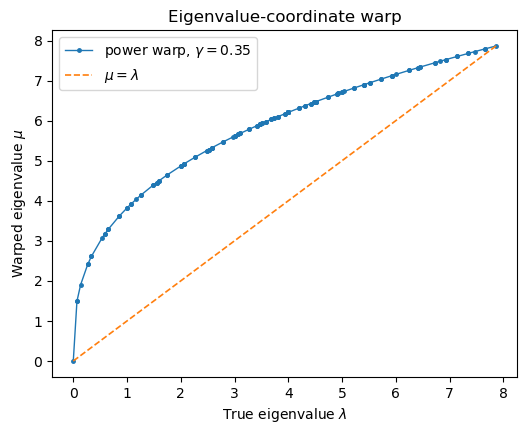

In [29]:
def power_warp(lam, gamma):
    lam = np.asarray(lam, dtype=float)
    lam_max = float(lam.max())

    warped = lam_max * (
        np.clip(lam, 0.0, None) / lam_max
    ) ** gamma
    warped[lam <= ZERO_TOL] = 0.0
    return warped


lam_warp = power_warp(
    lam_true,
    gamma=POWER_GAMMA,
)

U_warp = U_true.copy()

lam_warp_t = torch.tensor(
    lam_warp,
    dtype=torch.double,
    device=DEVICE,
)
U_warp_t = torch.tensor(
    U_warp,
    dtype=torch.double,
    device=DEVICE,
)

# Eigenvalue-warp diagnostic.
plt.figure(figsize=(6, 4.5))
plt.plot(
    lam_true,
    lam_warp,
    marker="o",
    markersize=2.5,
    linewidth=1.0,
    label=fr"power warp, $\gamma={POWER_GAMMA}$",
)
plt.plot(
    [0.0, lam_true.max()],
    [0.0, lam_true.max()],
    linestyle="--",
    linewidth=1.2,
    label=r"$\mu=\lambda$",
)
plt.xlabel(r"True eigenvalue $\lambda$")
plt.ylabel(r"Warped eigenvalue $\mu$")
plt.title("Eigenvalue-coordinate warp")
plt.legend()
plt.show()

## 7. Construct the exact target covariance and precision spectra

For each unchanged eigenvector, retain the true spectral value

$$
F_{\mathrm{target},i}
=
F_{\mathrm{true}}(\lambda_i),
\qquad
q_{\mathrm{target},i}
=
\frac{1}{F_{\mathrm{target},i}}.
$$

The target values themselves are **not warped**. They are the true covariance/precision values evaluated at the true mode and then plotted or modeled against the warped coordinate $\mu_i$.

In [6]:
# The true precision values are determined by the true eigenvalues.
q_true = (
    (1.0 - RHO_TRUE)
    + RHO_TRUE * lam_true
) / TAU2_TRUE

# Under the controlled warp, only the horizontal coordinate changes:
#   lambda_i -> mu_i.
# The modal target values themselves stay attached to the same eigenvectors.
F_target = F_true.copy()
q_target = q_true.copy()

np.testing.assert_allclose(
    q_target,
    1.0 / F_target,
    rtol=1e-12,
    atol=1e-12,
)

positive_mode_mask = lam_true > ZERO_TOL

q_target_t = torch.tensor(
    q_target,
    dtype=torch.double,
    device=DEVICE,
)

print("Target covariance range:", (F_target.min(), F_target.max()))
print("Target precision range:", (q_target.min(), q_target.max()))

Target covariance range: (np.float64(0.09569892081705346), np.float64(8.750000000000004))
Target precision range: (np.float64(0.11428571428571424), np.float64(10.449438629633962))


## 8. Holdout construction

Create the selected contiguous holdout block, corresponding train/test masks, and the tensors `y_fit_t`, `y_test_t`, and `is_holdout_t`. This fixes the prediction problem before either model is fit; the plot verifies the held-out region spatially.


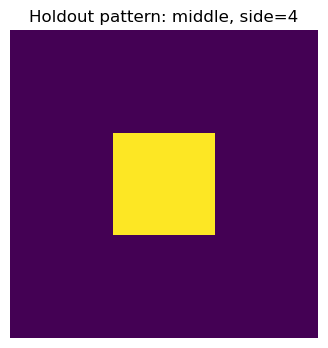

Training nodes: 128
Held-out nodes: 16
Holdout fraction: 0.1111111111111111


In [30]:
def holdout_block_mask(n_rows, n_cols, side, pattern):
    if side <= 0:
        raise ValueError("side must be positive.")
    if side > n_rows or side > n_cols:
        raise ValueError(
            "side must not exceed either grid dimension."
        )
    if pattern not in HOLDOUT_OPTIONS:
        raise ValueError(
            f"Unknown holdout pattern: {pattern}."
        )

    mask = np.zeros((n_rows, n_cols), dtype=bool)

    row_center = (n_rows - side) // 2
    col_center = (n_cols - side) // 2

    if pattern == "middle":
        mask[
            row_center:row_center + side,
            col_center:col_center + side,
        ] = True

    elif pattern == "left":
        mask[
            row_center:row_center + side,
            :side,
        ] = True

    elif pattern == "right":
        mask[
            row_center:row_center + side,
            n_cols - side:,
        ] = True

    elif pattern == "top":
        mask[
            :side,
            col_center:col_center + side,
        ] = True

    elif pattern == "down":
        mask[
            n_rows - side:,
            col_center:col_center + side,
        ] = True


    return mask.ravel()


test_mask = holdout_block_mask(
    N_ROWS,
    N_COLS,
    HOLDOUT_SIDE,
    HOLDOUT_PATTERN,
)
train_mask = ~test_mask

X_t = torch.tensor(
    X,
    dtype=torch.double,
    device=DEVICE,
)
y_all_t = torch.tensor(
    y,
    dtype=torch.double,
    device=DEVICE,
)
is_holdout_t = torch.tensor(
    test_mask,
    dtype=torch.bool,
    device=DEVICE,
)

y_test_t = y_all_t[is_holdout_t].clone()
y_fit_t = y_all_t.clone()
y_fit_t[is_holdout_t] = torch.nan

prior_V0 = BETA_PRIOR_VAR * torch.eye(
    X_t.shape[1],
    dtype=torch.double,
    device=DEVICE,
)

# Holdout-region diagnostic.
plt.figure(figsize=(4.5, 4.0))
plt.imshow(
    test_mask.reshape(N_ROWS, N_COLS),
    interpolation="nearest",
)
plt.title(
    f"Holdout pattern: {HOLDOUT_PATTERN}, side={HOLDOUT_SIDE}"
)
plt.axis("off")
plt.show()

print("Training nodes:", int(train_mask.sum()))
print("Held-out nodes:", int(test_mask.sum()))
print("Holdout fraction:", float(test_mask.mean()))

## 9. Model and filter constructors

Define the Leroux filter, the locked adaptive precision P-spline filter, and the shared `SpectralCAR_HoldoutVI` fitting helper. Both likelihood fits use the same warped eigensystem, data, fixed observation variance, beta prior, holdout mask, optimizer family, and likelihood. The substantive model difference is the spectral filter family.


In [8]:
def rho_to_raw(rho, rho_eps=LEROUX_RHO_EPS):
    probability = rho / (1.0 - rho_eps)
    if not 0.0 < probability < 1.0:
        raise ValueError(
            "rho is incompatible with rho_eps."
        )
    return math.log(
        probability / (1.0 - probability)
    )


def make_leroux_filter():
    return LerouxCARFilterFullVI(
        mu_log_tau2=math.log(INIT_LEROUX_TAU2),
        log_std_log_tau2=LEROUX_LOG_STD_INIT,
        mu_rho_raw=rho_to_raw(INIT_LEROUX_RHO),
        log_std_rho_raw=LEROUX_LOG_STD_INIT,
        fixed_rho=None,
        rho_eps=LEROUX_RHO_EPS,
    ).to(DEVICE)


def make_pspline_filter(lam_t):
    return AdaptivePrecisionPSplineFullVI(
        lam_max=float(lam_t.max().item()),
        mu_log_q_left=math.log(INIT_Q_LEFT),
        mu_log_q_right=math.log(INIT_Q_RIGHT),
        **ADAPTIVE_PSPLINE_KWARGS,
    ).to(DEVICE)


_structure_check = make_pspline_filter(lam_warp_t)
print(
    "Adaptive P-spline:",
    f"J={_structure_check.J} basis coefficients,",
    f"K={_structure_check.K} second differences.",
)
del _structure_check

Adaptive P-spline: J=8 basis coefficients, K=6 second differences.


In [9]:
def fit_spectral_vi(
    *,
    label,
    filter_module,
    iterations,
    learning_rate,
    seed,
):
    np.random.seed(seed)
    torch.manual_seed(seed)

    model = SpectralCAR_HoldoutVI(
        X=X_t,
        y=y_fit_t,
        lam=lam_warp_t,
        U=U_warp_t,
        filter_module=filter_module,
        is_holdout=is_holdout_t,
        prior_m0=None,
        prior_V0=prior_V0,
        mu_log_sigma2=math.log(SIGMA2_TRUE),
        log_std_log_sigma2=-2.3,
        num_mc=NUM_MC,
        fixed_sigma2=SIGMA2_TRUE,
        jitter=JITTER,
    ).to(DEVICE)

    parameters = [
        parameter
        for parameter in model.parameters()
        if parameter.requires_grad
    ]

    optimizer = torch.optim.Adam(
        parameters,
        lr=learning_rate,
    )

    history = []

    for iteration in range(1, iterations + 1):
        optimizer.zero_grad(set_to_none=True)

        elbo, _ = model.elbo()
        loss = -elbo

        if not torch.isfinite(loss):
            raise RuntimeError(
                f"{label}: non-finite loss at "
                f"iteration {iteration}."
            )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            parameters,
            GRAD_CLIP,
        )
        optimizer.step()

        history.append(
            float(elbo.detach().cpu())
        )

        if iteration % 500 == 0:
            print(
                f"{label}: {iteration}/{iterations}, "
                f"mean last 100 ELBO="
                f"{np.mean(history[-100:]):.3f}"
            )

    return {
        "label": label,
        "model": model,
        "history": np.asarray(history, dtype=float),
    }


# PART I — REPRESENTATIONAL CAPACITY

## 10. Direct target-capacity experiment

> **Capacity test — no likelihood and no statistical estimation**

Fit each spectral family directly to the known target precision $q_{\mathrm{target}}(\mu)$. This separates a representational question from posterior estimation: can the family itself express the nonlinear warped-coordinate target?

Report the best direct Leroux and P-spline precisions, ordinary and positive-mode log-spectrum RMSE, and the P-spline curvature diagnostic.

,model,log_precision_RMSE,positive_mode_log_precision_RMSE,d2_l2
0,Leroux CAR,0.495503,0.495371,NaN
1,Adaptive P-spline,0.003914,0.003927,2.214052


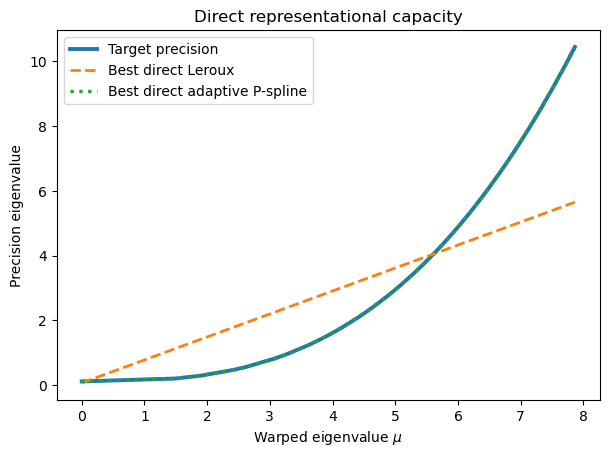

In [31]:
def log_spectrum_rmse(estimated, target, mask=None):
    estimated = np.asarray(estimated, dtype=float)
    target = np.asarray(target, dtype=float)

    if mask is not None:
        mask = np.asarray(mask, dtype=bool)
        estimated = estimated[mask]
        target = target[mask]

    estimated = np.clip(estimated, 1e-12, None)
    target = np.clip(target, 1e-12, None)

    return float(
        np.sqrt(
            np.mean(
                (
                    np.log(estimated)
                    - np.log(target)
                ) ** 2
            )
        )
    )


def direct_leroux_theta(filter_module):
    return {
        "log_tau2": filter_module.mu_log_tau2.reshape(1),
        "rho_raw": filter_module.mu_rho_raw.reshape(1),
    }


def direct_pspline_theta(filter_module):
    # Local scales define the hierarchical prior, not the deterministic
    # precision mapping. Capacity therefore depends only on endpoints + d2.
    theta = {
        "log_q_left":
            filter_module.mu_log_q_endpoints[0:1],
        "log_q_right":
            filter_module.mu_log_q_endpoints[1:2],
    }
    for j in range(filter_module.K):
        theta[f"d2_{j}_raw"] = (
            filter_module.mu_d2[j:j + 1]
        )
    return theta


# ----- Direct Leroux capacity fit -----
direct_leroux = make_leroux_filter()

optimizer = torch.optim.Adam(
    [
        direct_leroux.mu_log_tau2,
        direct_leroux.mu_rho_raw,
    ],
    lr=DIRECT_LEROUX_LR,
)

for iteration in range(1, DIRECT_LEROUX_ITERS + 1):
    optimizer.zero_grad(set_to_none=True)

    F_fit = direct_leroux.spectrum(
        lam_warp_t,
        direct_leroux_theta(direct_leroux),
    ).clamp_min(1e-12)
    q_fit = 1.0 / F_fit

    loss = torch.mean(
        (
            torch.log(q_fit)
            - torch.log(q_target_t)
        ) ** 2
    )
    loss.backward()
    torch.nn.utils.clip_grad_norm_(
        [
            direct_leroux.mu_log_tau2,
            direct_leroux.mu_rho_raw,
        ],
        GRAD_CLIP,
    )
    optimizer.step()

with torch.no_grad():
    F_direct_leroux = (
        direct_leroux
        .spectrum(
            lam_warp_t,
            direct_leroux_theta(direct_leroux),
        )
        .detach()
        .cpu()
        .numpy()
    )
q_direct_leroux = 1.0 / np.clip(
    F_direct_leroux,
    1e-12,
    None,
)


# ----- Direct adaptive P-spline capacity fit -----
direct_pspline = make_pspline_filter(lam_warp_t)

optimizer = torch.optim.Adam(
    [
        direct_pspline.mu_log_q_endpoints,
        direct_pspline.mu_d2,
    ],
    lr=DIRECT_PSPLINE_LR,
)

for iteration in range(1, DIRECT_PSPLINE_ITERS + 1):
    optimizer.zero_grad(set_to_none=True)

    q_fit = direct_pspline.precision_from_unconstrained(
        lam_warp_t,
        direct_pspline_theta(direct_pspline),
    )

    loss = torch.mean(
        (
            torch.log(q_fit)
            - torch.log(q_target_t)
        ) ** 2
    )
    loss.backward()
    torch.nn.utils.clip_grad_norm_(
        [
            direct_pspline.mu_log_q_endpoints,
            direct_pspline.mu_d2,
        ],
        GRAD_CLIP,
    )
    optimizer.step()

with torch.no_grad():
    q_direct_pspline = (
        direct_pspline
        .precision_from_unconstrained(
            lam_warp_t,
            direct_pspline_theta(direct_pspline),
        )
        .detach()
        .cpu()
        .numpy()
    )

direct_d2_l2 = float(
    direct_pspline
    .shrinkage_summary()["d2_l2"]
    .detach()
    .cpu()
)

direct_capacity_table = pd.DataFrame(
    [
        {
            "model": "Leroux CAR",
            "log_precision_RMSE":
                log_spectrum_rmse(
                    q_direct_leroux,
                    q_target,
                ),
            "positive_mode_log_precision_RMSE":
                log_spectrum_rmse(
                    q_direct_leroux,
                    q_target,
                    positive_mode_mask,
                ),
            "d2_l2": np.nan,
        },
        {
            "model": "Adaptive P-spline",
            "log_precision_RMSE":
                log_spectrum_rmse(
                    q_direct_pspline,
                    q_target,
                ),
            "positive_mode_log_precision_RMSE":
                log_spectrum_rmse(
                    q_direct_pspline,
                    q_target,
                    positive_mode_mask,
                ),
            "d2_l2": direct_d2_l2,
        },
    ]
)

display(direct_capacity_table)

# Direct target-capacity comparison.
order = np.argsort(lam_warp)

plt.figure(figsize=(7, 4.8))
plt.plot(
    lam_warp[order],
    q_target[order],
    linewidth=2.8,
    label="Target precision",
)
plt.plot(
    lam_warp[order],
    q_direct_leroux[order],
    linestyle="--",
    linewidth=2.0,
    label="Best direct Leroux",
)
plt.plot(
    lam_warp[order],
    q_direct_pspline[order],
    linestyle=":",
    linewidth=2.4,
    label="Best direct adaptive P-spline",
)
plt.xlabel(r"Warped eigenvalue $\mu$")
plt.ylabel("Precision eigenvalue")
plt.title("Direct representational capacity")
plt.legend()
plt.show()

# PART II — LIKELIHOOD-BASED ESTIMATION

## 11. Fit Leroux and Adaptive P-spline using VI

Now remove direct access to the target spectrum. Fit `leroux_result` and `pspline_result` to the same observed training data using the same warped eigenvalues, warped eigenvectors, holdout mask, fixed observation variance, regression prior, and likelihood. The substantive difference is the spectral filter family.


In [11]:
leroux_result = fit_spectral_vi(
    label="Leroux CAR",
    filter_module=make_leroux_filter(),
    iterations=LEROUX_ITERS,
    learning_rate=LEROUX_LR,
    seed=SEED,
)

pspline_result = fit_spectral_vi(
    label="Adaptive P-spline SDM-CAR",
    filter_module=make_pspline_filter(lam_warp_t),
    iterations=PSPLINE_ITERS,
    learning_rate=PSPLINE_LR,
    seed=SEED,
)

Leroux CAR: 500/3000, mean last 100 ELBO=-29.431
Leroux CAR: 1000/3000, mean last 100 ELBO=-22.727
Leroux CAR: 1500/3000, mean last 100 ELBO=-22.088
Leroux CAR: 2000/3000, mean last 100 ELBO=-21.778
Leroux CAR: 2500/3000, mean last 100 ELBO=-21.717
Leroux CAR: 3000/3000, mean last 100 ELBO=-21.649
Adaptive P-spline SDM-CAR: 500/6000, mean last 100 ELBO=-59.768
Adaptive P-spline SDM-CAR: 1000/6000, mean last 100 ELBO=-45.183
Adaptive P-spline SDM-CAR: 1500/6000, mean last 100 ELBO=-40.797
Adaptive P-spline SDM-CAR: 2000/6000, mean last 100 ELBO=-37.889
Adaptive P-spline SDM-CAR: 2500/6000, mean last 100 ELBO=-35.793
Adaptive P-spline SDM-CAR: 3000/6000, mean last 100 ELBO=-33.889
Adaptive P-spline SDM-CAR: 3500/6000, mean last 100 ELBO=-32.356
Adaptive P-spline SDM-CAR: 4000/6000, mean last 100 ELBO=-31.058
Adaptive P-spline SDM-CAR: 4500/6000, mean last 100 ELBO=-29.824
Adaptive P-spline SDM-CAR: 5000/6000, mean last 100 ELBO=-28.737
Adaptive P-spline SDM-CAR: 5500/6000, mean last 100 

## 12. Optimization diagnostics

Inspect both ELBO histories immediately after fitting. This checks optimization behavior before any posterior spectral or predictive interpretation.


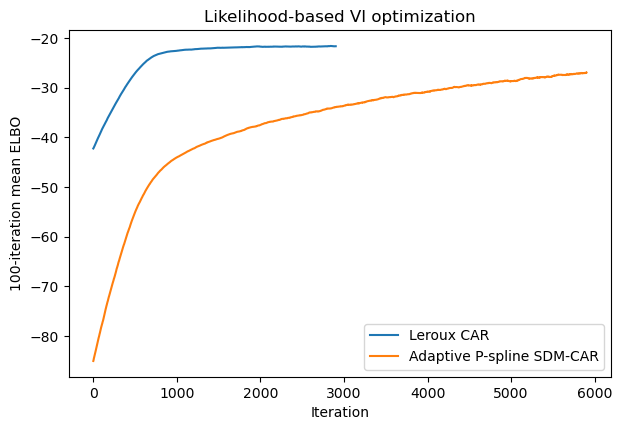

In [32]:
def moving_average(values, window=100):
    values = np.asarray(values, dtype=float)
    if values.size < window:
        return values
    kernel = np.ones(window) / window
    return np.convolve(values, kernel, mode="valid")


# ELBO histories.
plt.figure(figsize=(7, 4.5))

for result in (leroux_result, pspline_result):
    smoothed = moving_average(
        result["history"],
        window=100,
    )
    plt.plot(
        np.arange(smoothed.size) + 1,
        smoothed,
        label=result["label"],
    )

plt.xlabel("Iteration")
plt.ylabel("100-iteration mean ELBO")
plt.title("Likelihood-based VI optimization")
plt.legend()
plt.show()

## 13. Posterior spectral recovery

Use the fitted VI posteriors to summarize

$$
E[F \mid y_O],
\qquad
E[q \mid y_O],
$$

and pointwise 95% intervals against the exact target.

Also summarize the Leroux posterior parameters and decompose the adaptive P-spline precision into its affine component and nonlinear correction.

This asks whether the nonlinear target can actually be learned from data, rather than merely represented in the direct-capacity test.

Leroux parameters are estimated on the warped operator; the true-operator values are shown only as references.


,parameter,true_operator_value,mean,lower_95,upper_95
0,tau2,0.70,1.406355,0.989538,1.934700
1,rho,0.92,0.711736,0.468906,0.887529


Adaptive P-spline shrinkage/curvature summaries:


,quantity,posterior_mean,lower_95,upper_95
0,d2_l2,1.326702,0.931301,1.729032
1,max_abs_d2,1.014731,0.704100,1.389509
2,mean_local_scale,0.961349,0.640224,1.415138
3,max_local_scale,2.481220,1.322203,4.301317


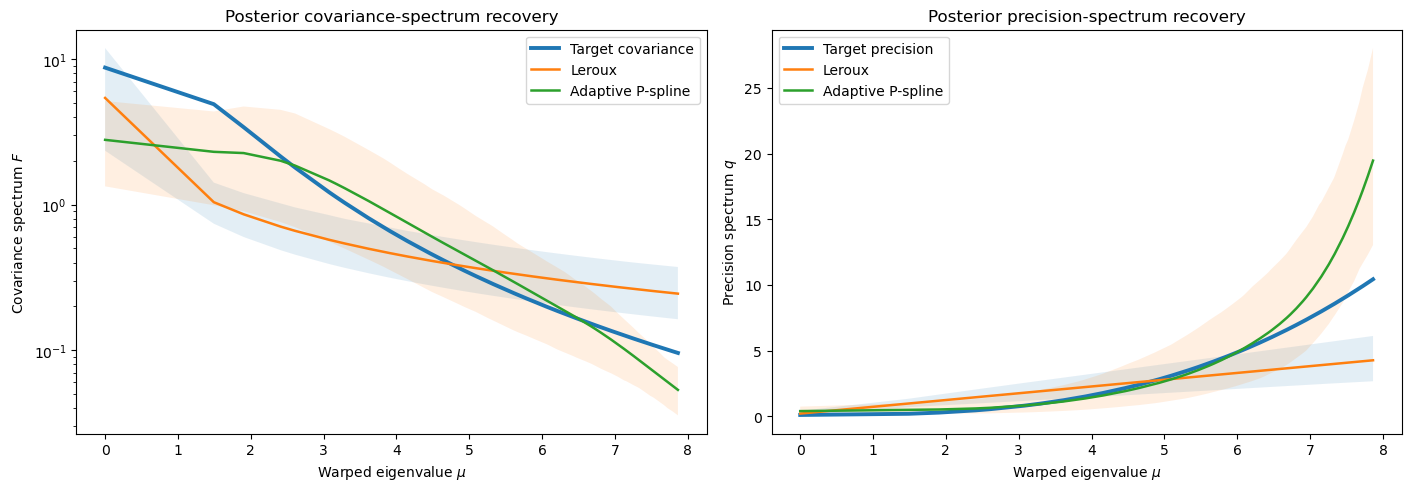

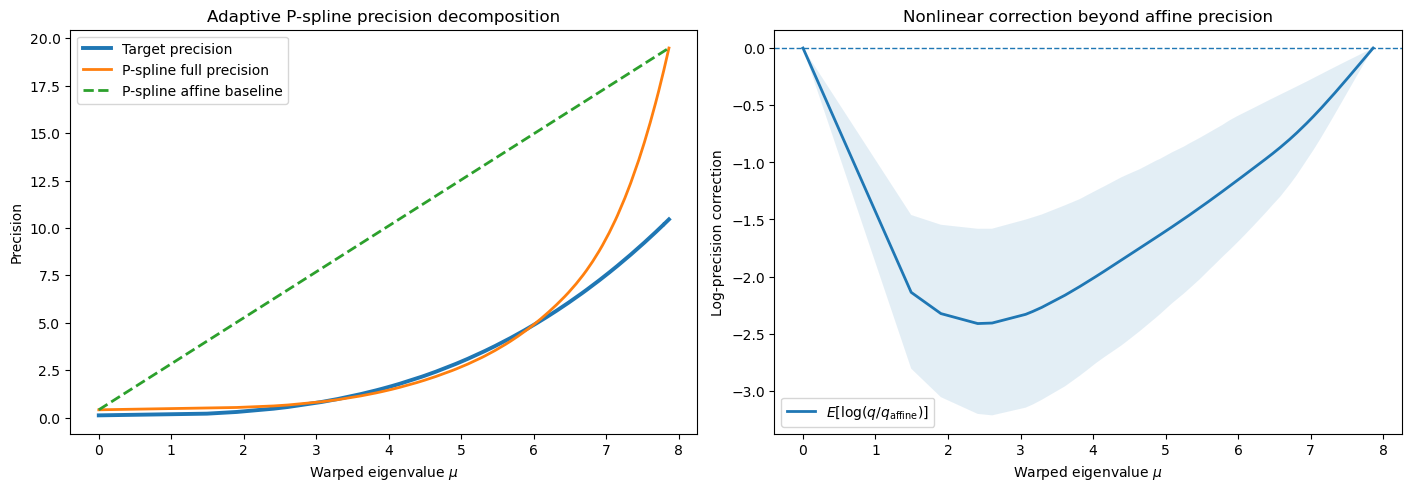

In [33]:
def summarize_draw_matrix(draws, credible_level=0.95):
    tail = (1.0 - credible_level) / 2.0
    return {
        "mean": draws.mean(dim=0),
        "lower": torch.quantile(
            draws,
            tail,
            dim=0,
        ),
        "upper": torch.quantile(
            draws,
            1.0 - tail,
            dim=0,
        ),
    }


@torch.no_grad()
def posterior_spectrum_summary(
    result,
    draws,
    seed,
):
    torch.manual_seed(seed)

    model = result["model"]
    F_draws = []

    for _ in range(draws):
        theta = model.filter.sample_unconstrained()
        F_draws.append(
            model.filter
            .spectrum(
                model.lam,
                theta,
            )
            .clamp_min(1e-12)
        )

    F_draws = torch.stack(F_draws, dim=0)
    q_draws = 1.0 / F_draws

    F_summary = summarize_draw_matrix(F_draws)
    q_summary = summarize_draw_matrix(q_draws)

    def np_(x):
        return x.detach().cpu().numpy()

    return {
        "F_mean": np_(F_summary["mean"]),
        "F_lower": np_(F_summary["lower"]),
        "F_upper": np_(F_summary["upper"]),
        "q_mean": np_(q_summary["mean"]),
        "q_lower": np_(q_summary["lower"]),
        "q_upper": np_(q_summary["upper"]),
    }


@torch.no_grad()
def posterior_pspline_component_summary(
    result,
    draws,
    seed,
):
    torch.manual_seed(seed)

    filt = result["model"].filter
    lam_t = result["model"].lam

    q_full_draws = []
    q_affine_draws = []
    log_correction_draws = []

    for _ in range(draws):
        theta = filt.sample_unconstrained()

        q_full = filt.precision_from_unconstrained(
            lam_t,
            theta,
        )
        q_affine = (
            filt.affine_precision_from_unconstrained(
                lam_t,
                theta,
            )
        )

        q_full_draws.append(q_full)
        q_affine_draws.append(q_affine)
        log_correction_draws.append(
            torch.log(
                q_full.clamp_min(1e-12)
                / q_affine.clamp_min(1e-12)
            )
        )

    summaries = {
        "q_full": summarize_draw_matrix(
            torch.stack(q_full_draws, dim=0)
        ),
        "q_affine": summarize_draw_matrix(
            torch.stack(q_affine_draws, dim=0)
        ),
        "log_correction": summarize_draw_matrix(
            torch.stack(log_correction_draws, dim=0)
        ),
    }

    def np_(x):
        return x.detach().cpu().numpy()

    out = {}
    for name, summary in summaries.items():
        for key, value in summary.items():
            out[f"{name}_{key}"] = np_(value)

    return out


@torch.no_grad()
def posterior_leroux_parameter_summary(
    result,
    draws,
    seed,
):
    torch.manual_seed(seed)
    filt = result["model"].filter

    tau2_draws = []
    rho_draws = []

    for _ in range(draws):
        constrained = filt._constrain(
            filt.sample_unconstrained()
        )
        tau2_draws.append(
            constrained["tau2"].reshape(())
        )
        rho_draws.append(
            constrained["rho"].reshape(())
        )

    tau2_draws = torch.stack(tau2_draws)
    rho_draws = torch.stack(rho_draws)

    def scalar_summary(draws_t):
        return {
            "mean": float(draws_t.mean().cpu()),
            "lower_95": float(
                torch.quantile(
                    draws_t,
                    0.025,
                ).cpu()
            ),
            "upper_95": float(
                torch.quantile(
                    draws_t,
                    0.975,
                ).cpu()
            ),
        }

    return {
        "tau2": scalar_summary(tau2_draws),
        "rho": scalar_summary(rho_draws),
    }


@torch.no_grad()
def posterior_pspline_shrinkage_summary(
    result,
    draws,
    seed,
):
    torch.manual_seed(seed)
    filt = result["model"].filter

    d2_l2 = []
    max_abs_d2 = []
    mean_local_scale = []
    max_local_scale = []

    for _ in range(draws):
        theta = filt.sample_unconstrained()
        constrained = filt._constrain(theta)

        d2 = constrained["d2"]
        local_scales = torch.exp(
            torch.stack(
                [
                    theta[f"log_lambda_{j}"].reshape(())
                    for j in range(filt.K)
                ]
            )
        )

        d2_l2.append(torch.linalg.vector_norm(d2))
        max_abs_d2.append(torch.max(torch.abs(d2)))
        mean_local_scale.append(local_scales.mean())
        max_local_scale.append(local_scales.max())

    metrics = {
        "d2_l2": torch.stack(d2_l2),
        "max_abs_d2": torch.stack(max_abs_d2),
        "mean_local_scale": torch.stack(
            mean_local_scale
        ),
        "max_local_scale": torch.stack(
            max_local_scale
        ),
    }

    rows = []
    for name, draws_t in metrics.items():
        rows.append(
            {
                "quantity": name,
                "posterior_mean":
                    float(draws_t.mean().cpu()),
                "lower_95":
                    float(
                        torch.quantile(
                            draws_t,
                            0.025,
                        ).cpu()
                    ),
                "upper_95":
                    float(
                        torch.quantile(
                            draws_t,
                            0.975,
                        ).cpu()
                    ),
            }
        )

    return pd.DataFrame(rows)


leroux_post = posterior_spectrum_summary(
    leroux_result,
    draws=POSTERIOR_SPECTRUM_DRAWS,
    seed=SEED + 20_001,
)

pspline_post = posterior_spectrum_summary(
    pspline_result,
    draws=POSTERIOR_SPECTRUM_DRAWS,
    seed=SEED + 20_002,
)

pspline_components = (
    posterior_pspline_component_summary(
        pspline_result,
        draws=POSTERIOR_SPECTRUM_DRAWS,
        seed=SEED + 20_002,
    )
)

leroux_parameters = (
    posterior_leroux_parameter_summary(
        leroux_result,
        draws=POSTERIOR_PARAMETER_DRAWS,
        seed=SEED + 20_101,
    )
)

leroux_parameter_table = pd.DataFrame(
    [
        {
            "parameter": "tau2",
            "true_operator_value": TAU2_TRUE,
            **leroux_parameters["tau2"],
        },
        {
            "parameter": "rho",
            "true_operator_value": RHO_TRUE,
            **leroux_parameters["rho"],
        },
    ]
)

pspline_shrinkage_table = (
    posterior_pspline_shrinkage_summary(
        pspline_result,
        draws=POSTERIOR_PARAMETER_DRAWS,
        seed=SEED + 20_202,
    )
)

print(
    "Leroux parameters are estimated on the warped operator; "
    "the true-operator values are shown only as references."
)
display(leroux_parameter_table)

print("Adaptive P-spline shrinkage/curvature summaries:")
display(pspline_shrinkage_table)


# Likelihood-based posterior spectral recovery.
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 4.8),
    constrained_layout=True,
)

axes[0].plot(
    lam_warp[order],
    F_target[order],
    linewidth=2.8,
    label="Target covariance",
)
for post, label in [
    (leroux_post, "Leroux"),
    (pspline_post, "Adaptive P-spline"),
]:
    axes[0].plot(
        lam_warp[order],
        post["F_mean"][order],
        linewidth=1.8,
        label=label,
    )
    axes[0].fill_between(
        lam_warp[order],
        post["F_lower"][order],
        post["F_upper"][order],
        alpha=0.12,
    )

axes[0].set_yscale("log")
axes[0].set_xlabel(r"Warped eigenvalue $\mu$")
axes[0].set_ylabel(r"Covariance spectrum $F$")
axes[0].set_title("Posterior covariance-spectrum recovery")
axes[0].legend()

axes[1].plot(
    lam_warp[order],
    q_target[order],
    linewidth=2.8,
    label="Target precision",
)
for post, label in [
    (leroux_post, "Leroux"),
    (pspline_post, "Adaptive P-spline"),
]:
    axes[1].plot(
        lam_warp[order],
        post["q_mean"][order],
        linewidth=1.8,
        label=label,
    )
    axes[1].fill_between(
        lam_warp[order],
        post["q_lower"][order],
        post["q_upper"][order],
        alpha=0.12,
    )

axes[1].set_xlabel(r"Warped eigenvalue $\mu$")
axes[1].set_ylabel(r"Precision spectrum $q$")
axes[1].set_title("Posterior precision-spectrum recovery")
axes[1].legend()

plt.show()


# Affine baseline versus nonlinear correction.
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 4.8),
    constrained_layout=True,
)

axes[0].plot(
    lam_warp[order],
    q_target[order],
    linewidth=2.8,
    label="Target precision",
)
axes[0].plot(
    lam_warp[order],
    pspline_components["q_full_mean"][order],
    linewidth=2.0,
    label="P-spline full precision",
)
axes[0].plot(
    lam_warp[order],
    pspline_components["q_affine_mean"][order],
    linestyle="--",
    linewidth=2.0,
    label="P-spline affine baseline",
)
axes[0].set_xlabel(r"Warped eigenvalue $\mu$")
axes[0].set_ylabel("Precision")
axes[0].set_title("Adaptive P-spline precision decomposition")
axes[0].legend()

axes[1].plot(
    lam_warp[order],
    pspline_components[
        "log_correction_mean"
    ][order],
    linewidth=2.0,
    label=r"$E[\log(q/q_{\mathrm{affine}})]$",
)
axes[1].fill_between(
    lam_warp[order],
    pspline_components[
        "log_correction_lower"
    ][order],
    pspline_components[
        "log_correction_upper"
    ][order],
    alpha=0.12,
)
axes[1].axhline(
    0.0,
    linestyle="--",
    linewidth=1.0,
)
axes[1].set_xlabel(r"Warped eigenvalue $\mu$")
axes[1].set_ylabel("Log-precision correction")
axes[1].set_title("Nonlinear correction beyond affine precision")
axes[1].legend()

plt.show()

## 14. Spectral recovery metrics

Quantify the posterior spectral plots using ordinary, positive-mode, variance-weighted, and low/mid/high-frequency log-spectrum RMSE. These metrics summarize where each posterior mean spectrum succeeds or fails across the warped coordinate.


In [14]:
def variance_weighted_log_spectrum_rmse(
    estimated,
    target,
    mask=None,
):
    estimated = np.asarray(estimated, dtype=float)
    target = np.asarray(target, dtype=float)

    if mask is None:
        mask = np.ones(target.shape, dtype=bool)
    else:
        mask = np.asarray(mask, dtype=bool)

    estimated = np.clip(
        estimated[mask],
        1e-12,
        None,
    )
    target = np.clip(
        target[mask],
        1e-12,
        None,
    )

    weights = target / target.sum()
    squared_log_error = (
        np.log(estimated) - np.log(target)
    ) ** 2

    return float(
        np.sqrt(
            np.sum(weights * squared_log_error)
        )
    )


def frequency_band_masks(lam, positive_mask):
    positive_idx = np.flatnonzero(
        np.asarray(positive_mask, dtype=bool)
    )
    positive_idx = positive_idx[
        np.argsort(
            np.asarray(lam)[positive_idx]
        )
    ]

    low_idx, mid_idx, high_idx = np.array_split(
        positive_idx,
        3,
    )

    out = {}
    for name, idx in [
        ("low", low_idx),
        ("mid", mid_idx),
        ("high", high_idx),
    ]:
        mask = np.zeros(
            len(lam),
            dtype=bool,
        )
        mask[idx] = True
        out[name] = mask

    return out


band_masks = frequency_band_masks(
    lam_warp,
    positive_mode_mask,
)


def spectral_metric_row(
    model_name,
    F_estimated,
):
    return {
        "model": model_name,
        "log_RMSE":
            log_spectrum_rmse(
                F_estimated,
                F_target,
            ),
        "positive_mode_log_RMSE":
            log_spectrum_rmse(
                F_estimated,
                F_target,
                positive_mode_mask,
            ),
        "variance_weighted_log_RMSE":
            variance_weighted_log_spectrum_rmse(
                F_estimated,
                F_target,
            ),
        "low_frequency_log_RMSE":
            log_spectrum_rmse(
                F_estimated,
                F_target,
                band_masks["low"],
            ),
        "mid_frequency_log_RMSE":
            log_spectrum_rmse(
                F_estimated,
                F_target,
                band_masks["mid"],
            ),
        "high_frequency_log_RMSE":
            log_spectrum_rmse(
                F_estimated,
                F_target,
                band_masks["high"],
            ),
    }


spectral_metrics = pd.DataFrame(
    [
        spectral_metric_row(
            "Leroux CAR",
            leroux_post["F_mean"],
        ),
        spectral_metric_row(
            "Adaptive P-spline SDM-CAR",
            pspline_post["F_mean"],
        ),
    ]
)

display(spectral_metrics)

,model,log_RMSE,positive_mode_log_RMSE,variance_weighted_log_RMSE,low_frequency_log_RMSE,mid_frequency_log_RMSE,high_frequency_log_RMSE
0,Leroux CAR,0.599300,0.600053,0.862975,0.566203,0.446714,0.751203
1,Adaptive P-spline SDM-CAR,0.259224,0.241931,0.539828,0.286797,0.112156,0.285014


# PART III — PREDICTIVE CONSEQUENCES

## 15. Held-out posterior prediction

Compute posterior predictive distributions for both the held-out response $y_H$ and latent field $\eta_H$.

For each model, retain posterior predictive uncertainty and calculate RMSE, NLPD, CRPS, 95% coverage, and mean 95% interval width.

In [15]:
def stable_cholesky(
    matrix,
    base_jitter=1e-10,
    max_tries=8,
):
    matrix = 0.5 * (matrix + matrix.T)

    eye = torch.eye(
        matrix.shape[0],
        dtype=matrix.dtype,
        device=matrix.device,
    )
    scale = (
        torch.diagonal(matrix)
        .abs()
        .mean()
        .detach()
        .clamp_min(1.0)
    )

    last_error = None

    for attempt in range(max_tries):
        jitter = (
            base_jitter
            * (10.0 ** attempt)
            * scale
        )
        try:
            return torch.linalg.cholesky(
                matrix + jitter * eye
            )
        except RuntimeError as error:
            last_error = error

    raise RuntimeError(
        "stable_cholesky failed."
    ) from last_error


@torch.no_grad()
def predict_eta_vi_mc(
    model,
    num_mc,
    seed,
):
    """
    Posterior predictive draws for eta_H = X_H beta + phi_H.

    The returned full covariance is the moment-matched posterior
    predictive covariance:
        E[V_H(theta)] + Cov(m_H(theta)).
    """
    K = int(num_mc)
    if K < 2:
        raise ValueError(
            "num_mc must be at least 2."
        )

    torch.manual_seed(seed)

    component_means = []
    component_vars = []
    draws = []

    second_moment_sum = torch.zeros(
        (model.n_test, model.n_test),
        dtype=model.y_train.dtype,
        device=model.y_train.device,
    )

    I_train = torch.eye(
        model.n_train,
        dtype=model.y_train.dtype,
        device=model.y_train.device,
    )

    for _ in range(K):
        sigma2 = model._sample_sigma2()
        theta = model.filter.sample_unconstrained()

        F_lam = (
            model.filter
            .spectrum(
                model.lam,
                theta,
            )
            .clamp_min(model.min_variance)
        )

        terms = model._observed_terms(
            F_lam,
            sigma2,
        )
        m_beta, V_beta = (
            model._beta_update_from_terms(
                terms
            )
        )

        S_HO = (
            model.U_test
            * F_lam.unsqueeze(0)
        ) @ model.U_train.T

        S_HH = (
            model.U_test
            * F_lam.unsqueeze(0)
        ) @ model.U_test.T

        S_OO = (
            model.U_train
            * F_lam.unsqueeze(0)
        ) @ model.U_train.T

        C_OO = (
            S_OO
            + sigma2 * I_train
        )
        chol_OO = stable_cholesky(
            C_OO,
            base_jitter=max(
                model.jitter,
                1e-10,
            ),
        )

        gain = torch.cholesky_solve(
            S_HO.T,
            chol_OO,
        ).T

        A_beta = (
            model.X_test
            - gain @ model.X_train
        )

        pred_mean = (
            gain @ model.y_train
            + A_beta @ m_beta
        )

        conditional_cov = (
            S_HH
            - gain @ S_HO.T
        )
        conditional_cov = 0.5 * (
            conditional_cov
            + conditional_cov.T
        )

        pred_cov = (
            conditional_cov
            + A_beta @ V_beta @ A_beta.T
        )
        pred_cov = 0.5 * (
            pred_cov + pred_cov.T
        )

        pred_var = torch.diagonal(
            pred_cov
        ).clamp_min(0.0)

        component_means.append(pred_mean)
        component_vars.append(pred_var)

        second_moment_sum += (
            pred_cov
            + torch.outer(
                pred_mean,
                pred_mean,
            )
        )

        chol_beta = torch.linalg.cholesky(
            V_beta
            + model.jitter * model.I_beta
        )
        beta_draw = (
            m_beta
            + chol_beta
            @ torch.randn(
                model.p,
                dtype=m_beta.dtype,
                device=m_beta.device,
            )
        )

        chol_eta = stable_cholesky(
            conditional_cov,
            base_jitter=max(
                model.jitter,
                1e-10,
            ),
        )
        eta_draw = (
            gain @ model.y_train
            + A_beta @ beta_draw
            + chol_eta
            @ torch.randn(
                model.n_test,
                dtype=m_beta.dtype,
                device=m_beta.device,
            )
        )
        draws.append(eta_draw)

    means = torch.stack(
        component_means,
        dim=0,
    )
    variances = torch.stack(
        component_vars,
        dim=0,
    )
    draws = torch.stack(draws, dim=0)

    mean = means.mean(dim=0)

    covariance = (
        second_moment_sum / float(K)
        - torch.outer(mean, mean)
    )
    covariance = 0.5 * (
        covariance + covariance.T
    )

    variance = torch.diagonal(
        covariance
    ).clamp_min(0.0)

    return {
        "mean": mean,
        "var": variance,
        "sd": torch.sqrt(variance),
        "cov": covariance,
        "q025": torch.quantile(
            draws,
            0.025,
            dim=0,
        ),
        "q975": torch.quantile(
            draws,
            0.975,
            dim=0,
        ),
        "draws": draws,
        "component_means": means,
        "component_vars": variances,
        "test_idx": model.test_idx,
    }


def marginal_mixture_nlpd(
    target,
    component_means,
    component_vars,
):
    target = torch.as_tensor(
        target,
        dtype=component_means.dtype,
        device=component_means.device,
    ).reshape(-1)

    variances = component_vars.clamp_min(1e-12)

    log_prob = -0.5 * (
        math.log(2.0 * math.pi)
        + torch.log(variances)
        + (
            target.unsqueeze(0)
            - component_means
        ).square()
        / variances
    )

    log_density = (
        torch.logsumexp(
            log_prob,
            dim=0,
        )
        - math.log(component_means.shape[0])
    )

    return float(
        (-log_density.mean()).detach().cpu()
    )


def crps_from_draws(target, draws):
    target = torch.as_tensor(
        target,
        dtype=draws.dtype,
        device=draws.device,
    ).reshape(-1)

    M = draws.shape[0]

    first_term = torch.mean(
        torch.abs(
            draws - target.unsqueeze(0)
        ),
        dim=0,
    )

    sorted_draws, _ = torch.sort(
        draws,
        dim=0,
    )
    ranks = torch.arange(
        1,
        M + 1,
        dtype=draws.dtype,
        device=draws.device,
    ).reshape(-1, 1)

    half_pairwise_term = (
        (
            (2.0 * ranks - M - 1.0)
            * sorted_draws
        ).sum(dim=0)
        / float(M * M)
    )

    return float(
        (
            first_term
            - half_pairwise_term
        ).mean().detach().cpu()
    )


def predictive_metrics(target, prediction):
    target_t = torch.as_tensor(
        target,
        dtype=prediction["mean"].dtype,
        device=prediction["mean"].device,
    ).reshape(-1)

    error = prediction["mean"] - target_t

    coverage = (
        (
            target_t >= prediction["q025"]
        )
        & (
            target_t <= prediction["q975"]
        )
    ).double().mean()

    return {
        "rmse": float(
            torch.sqrt(
                torch.mean(error.square())
            ).cpu()
        ),
        "nlpd": marginal_mixture_nlpd(
            target_t,
            prediction["component_means"],
            prediction["component_vars"],
        ),
        "crps": crps_from_draws(
            target_t,
            prediction["draws"],
        ),
        "coverage_95": float(coverage.cpu()),
        "interval_width_95": float(
            (
                prediction["q975"]
                - prediction["q025"]
            ).mean().cpu()
        ),
    }


PRED_SEED = SEED + 10_000

torch.manual_seed(PRED_SEED)
leroux_y_prediction = (
    leroux_result["model"]
    .predict_vi_mc(num_mc=PRED_MC)
)

torch.manual_seed(PRED_SEED)
pspline_y_prediction = (
    pspline_result["model"]
    .predict_vi_mc(num_mc=PRED_MC)
)

leroux_eta_prediction = predict_eta_vi_mc(
    leroux_result["model"],
    num_mc=PRED_MC,
    seed=PRED_SEED,
)
pspline_eta_prediction = predict_eta_vi_mc(
    pspline_result["model"],
    num_mc=PRED_MC,
    seed=PRED_SEED,
)

eta_test_t = torch.tensor(
    eta_true[test_mask],
    dtype=torch.double,
    device=DEVICE,
)

leroux_y_metrics = predictive_metrics(
    y_test_t,
    leroux_y_prediction,
)
pspline_y_metrics = predictive_metrics(
    y_test_t,
    pspline_y_prediction,
)
leroux_eta_metrics = predictive_metrics(
    eta_test_t,
    leroux_eta_prediction,
)
pspline_eta_metrics = predictive_metrics(
    eta_test_t,
    pspline_eta_prediction,
)

predictive_table = pd.DataFrame(
    [
        {
            "model": "Leroux CAR",
            "latent_RMSE": leroux_eta_metrics["rmse"],
            "response_RMSE": leroux_y_metrics["rmse"],
            "latent_NLPD": leroux_eta_metrics["nlpd"],
            "response_NLPD": leroux_y_metrics["nlpd"],
            "latent_CRPS": leroux_eta_metrics["crps"],
            "response_CRPS": leroux_y_metrics["crps"],
            "latent_coverage95":
                leroux_eta_metrics["coverage_95"],
            "response_coverage95":
                leroux_y_metrics["coverage_95"],
            "latent_width95":
                leroux_eta_metrics["interval_width_95"],
            "response_width95":
                leroux_y_metrics["interval_width_95"],
        },
        {
            "model": "Adaptive P-spline SDM-CAR",
            "latent_RMSE": pspline_eta_metrics["rmse"],
            "response_RMSE": pspline_y_metrics["rmse"],
            "latent_NLPD": pspline_eta_metrics["nlpd"],
            "response_NLPD": pspline_y_metrics["nlpd"],
            "latent_CRPS": pspline_eta_metrics["crps"],
            "response_CRPS": pspline_y_metrics["crps"],
            "latent_coverage95":
                pspline_eta_metrics["coverage_95"],
            "response_coverage95":
                pspline_y_metrics["coverage_95"],
            "latent_width95":
                pspline_eta_metrics["interval_width_95"],
            "response_width95":
                pspline_y_metrics["interval_width_95"],
        },
    ]
)

display(predictive_table)


,model,latent_RMSE,response_RMSE,latent_NLPD,response_NLPD,latent_CRPS,response_CRPS,latent_coverage95,response_coverage95,latent_width95,response_width95
0,Leroux CAR,0.393873,0.564274,0.599615,0.885194,0.233029,0.324912,1.0,1.0,2.272664,2.743980
1,Adaptive P-spline SDM-CAR,0.425315,0.556465,0.604133,0.861357,0.246881,0.315062,1.0,1.0,2.082503,2.543558


## 16. Variance calibration diagnostics

For the held-out latent field, evaluate

$$
z_i
=
\frac{\eta_i^\star - \hat{\eta}_i}{s_i},
\qquad
\mathrm{MSSE}
=
\frac{1}{h}\sum_i z_i^2.
$$

MSSE near 1 indicates calibration; values above 1 indicate intervals that are too narrow, and values below 1 indicate intervals that are too wide.

The normalized Mahalanobis diagnostic complements this with the full held-out covariance.

In [16]:
def latent_variance_calibration(
    target,
    prediction,
):
    target_t = torch.as_tensor(
        target,
        dtype=prediction["mean"].dtype,
        device=prediction["mean"].device,
    ).reshape(-1)

    residual = target_t - prediction["mean"]
    sd = prediction["sd"].clamp_min(1e-12)

    z = residual / sd
    msse = torch.mean(z.square())

    chol = stable_cholesky(
        prediction["cov"],
        base_jitter=1e-10,
    )
    solved = torch.cholesky_solve(
        residual.unsqueeze(1),
        chol,
    ).squeeze(1)

    normalized_mahalanobis = (
        residual @ solved
        / float(target_t.numel())
    )

    return {
        "MSSE": float(msse.cpu()),
        "normalized_Mahalanobis":
            float(normalized_mahalanobis.cpu()),
    }


leroux_calibration = (
    latent_variance_calibration(
        eta_test_t,
        leroux_eta_prediction,
    )
)
pspline_calibration = (
    latent_variance_calibration(
        eta_test_t,
        pspline_eta_prediction,
    )
)

calibration_table = pd.DataFrame(
    [
        {
            "model": "Leroux CAR",
            **leroux_calibration,
        },
        {
            "model": "Adaptive P-spline SDM-CAR",
            **pspline_calibration,
        },
    ]
)

display(calibration_table)
print(
    "Interpretation: MSSE and normalized Mahalanobis "
    "are ideally near 1."
)

,model,MSSE,normalized_Mahalanobis
0,Leroux CAR,0.461906,0.478163
1,Adaptive P-spline SDM-CAR,0.609475,0.805536


Interpretation: MSSE and normalized Mahalanobis are ideally near 1.


## 17. Final predictive comparison table

Combine held-out latent and response prediction, uncertainty calibration, and spectral recovery in one concise Leroux-versus-P-spline table. This is the main numerical summary of the predictive consequences of spectral recovery.


In [17]:
spectral_lookup = (
    spectral_metrics
    .set_index("model")
    .to_dict(orient="index")
)

final_comparison = pd.DataFrame(
    [
        {
            "model": "Leroux CAR",
            "latent_RMSE":
                leroux_eta_metrics["rmse"],
            "response_RMSE":
                leroux_y_metrics["rmse"],
            "latent_NLPD":
                leroux_eta_metrics["nlpd"],
            "response_NLPD":
                leroux_y_metrics["nlpd"],
            "latent_CRPS":
                leroux_eta_metrics["crps"],
            "response_CRPS":
                leroux_y_metrics["crps"],
            "latent_coverage95":
                leroux_eta_metrics["coverage_95"],
            "response_coverage95":
                leroux_y_metrics["coverage_95"],
            "latent_width95":
                leroux_eta_metrics["interval_width_95"],
            "response_width95":
                leroux_y_metrics["interval_width_95"],
            "latent_MSSE":
                leroux_calibration["MSSE"],
            "latent_Mahalanobis_per_site":
                leroux_calibration[
                    "normalized_Mahalanobis"
                ],
            "spectral_log_RMSE":
                spectral_lookup["Leroux CAR"][
                    "log_RMSE"
                ],
            "variance_weighted_spectral_log_RMSE":
                spectral_lookup["Leroux CAR"][
                    "variance_weighted_log_RMSE"
                ],
        },
        {
            "model": "Adaptive P-spline SDM-CAR",
            "latent_RMSE":
                pspline_eta_metrics["rmse"],
            "response_RMSE":
                pspline_y_metrics["rmse"],
            "latent_NLPD":
                pspline_eta_metrics["nlpd"],
            "response_NLPD":
                pspline_y_metrics["nlpd"],
            "latent_CRPS":
                pspline_eta_metrics["crps"],
            "response_CRPS":
                pspline_y_metrics["crps"],
            "latent_coverage95":
                pspline_eta_metrics["coverage_95"],
            "response_coverage95":
                pspline_y_metrics["coverage_95"],
            "latent_width95":
                pspline_eta_metrics["interval_width_95"],
            "response_width95":
                pspline_y_metrics["interval_width_95"],
            "latent_MSSE":
                pspline_calibration["MSSE"],
            "latent_Mahalanobis_per_site":
                pspline_calibration[
                    "normalized_Mahalanobis"
                ],
            "spectral_log_RMSE":
                spectral_lookup[
                    "Adaptive P-spline SDM-CAR"
                ]["log_RMSE"],
            "variance_weighted_spectral_log_RMSE":
                spectral_lookup[
                    "Adaptive P-spline SDM-CAR"
                ][
                    "variance_weighted_log_RMSE"
                ],
        },
    ]
)

display(final_comparison)

,model,latent_RMSE,response_RMSE,latent_NLPD,response_NLPD,latent_CRPS,response_CRPS,latent_coverage95,response_coverage95,latent_width95,response_width95,latent_MSSE,latent_Mahalanobis_per_site,spectral_log_RMSE,variance_weighted_spectral_log_RMSE
0,Leroux CAR,0.393873,0.564274,0.599615,0.885194,0.233029,0.324912,1.0,1.0,2.272664,2.743980,0.461906,0.478163,0.599300,0.862975
1,Adaptive P-spline SDM-CAR,0.425315,0.556465,0.604133,0.861357,0.246881,0.315062,1.0,1.0,2.082503,2.543558,0.609475,0.805536,0.259224,0.539828


## 18. Held-out latent prediction plot

After the numerical comparison, visualize the held-out latent posterior means and 95% intervals against the true latent field. This provides a site-level view of the predictive differences and uncertainty summarized above.


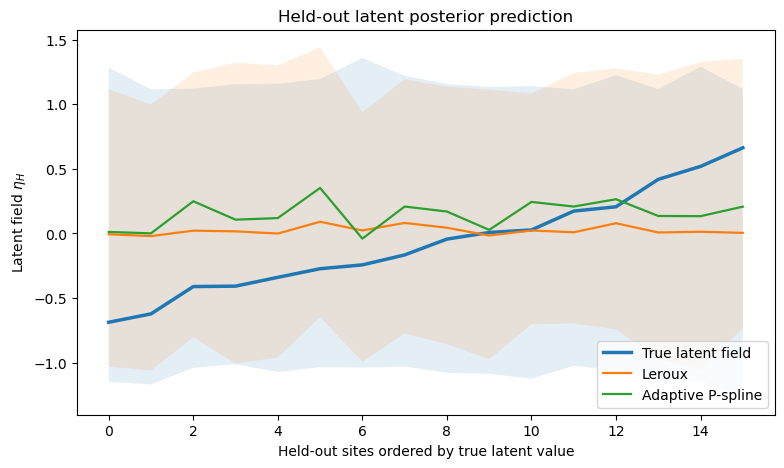

In [34]:
def plot_latent_intervals(
    truth,
    leroux_prediction,
    pspline_prediction,
):
    truth = np.asarray(truth, dtype=float)
    sort_idx = np.argsort(truth)
    x = np.arange(truth.size)

    plt.figure(figsize=(9, 5))
    plt.plot(
        x,
        truth[sort_idx],
        linewidth=2.5,
        label="True latent field",
    )

    for prediction, label in [
        (leroux_prediction, "Leroux"),
        (
            pspline_prediction,
            "Adaptive P-spline",
        ),
    ]:
        mean = (
            prediction["mean"]
            .detach()
            .cpu()
            .numpy()
        )[sort_idx]
        lower = (
            prediction["q025"]
            .detach()
            .cpu()
            .numpy()
        )[sort_idx]
        upper = (
            prediction["q975"]
            .detach()
            .cpu()
            .numpy()
        )[sort_idx]

        plt.plot(
            x,
            mean,
            linewidth=1.6,
            label=label,
        )
        plt.fill_between(
            x,
            lower,
            upper,
            alpha=0.12,
        )

    plt.xlabel("Held-out sites ordered by true latent value")
    plt.ylabel(r"Latent field $\eta_H$")
    plt.title("Held-out latent posterior prediction")
    plt.legend()
    plt.show()


# Held-out latent prediction with uncertainty.
plot_latent_intervals(
    eta_true[test_mask],
    leroux_eta_prediction,
    pspline_eta_prediction,
)

# PART IV — FULL PRECISION-OPERATOR RECOVERY

## 19. Introduce the full precision-operator analysis

A modal precision spectrum implies a latent spatial-domain precision operator

$$
Q
=
U \operatorname{diag}(q) U^\top.
$$

Because $U$ is fixed in this experiment,

$$
E[Q \mid y_O]
=
U \operatorname{diag}\!\left\{E[q \mid y_O]\right\} U^\top
$$

exactly.

Here $Q$ is the **model-implied latent prior precision operator with posterior uncertainty in its spectral parameters**. It is not the inverse of the posterior covariance of $\phi$.

This section therefore translates the already-estimated modal precision into node-space operator recovery without refitting either model.

## 20. Construct the target precision operator

Construct

$$
Q_{\mathrm{target}}
=
U_{\mathrm{true}}
\operatorname{diag}(q_{\mathrm{target}})
U_{\mathrm{true}}^\top
$$

and validate it against the Leroux spatial-domain identity

$$
Q_{\mathrm{target}}
=
\frac{1-\rho_0}{\tau_0^2} I
+
\frac{\rho_0}{\tau_0^2} L_{\mathrm{true}}.
$$

The proper Leroux zero mode is retained in the main analysis; the positive-mode operator is kept as a centered spatial diagnostic.

In [19]:
# ============================================================
# Posterior latent precision-operator diagnostics
# ============================================================
#
# Q(theta) = U diag(q(theta)) U^T.
#
# Here Q(theta) is the model-implied latent PRIOR precision
# operator. Its uncertainty comes from the variational posterior
# over the spectral/filter parameters given the observed data.
#
# Because U_warp is fixed,
#
#   E[Q | y_O]
#   = E[U diag(q) U^T | y_O]
#   = U diag(E[q | y_O]) U^T
#
# exactly. Therefore there is no reason to compute these as two
# separate quantities.


def precision_matrix_from_modes(U, q):
    """Construct U diag(q) U^T without explicitly forming diag(q)."""
    U = np.asarray(U, dtype=float)
    q = np.asarray(q, dtype=float).reshape(-1)

    if U.shape[1] != q.size:
        raise ValueError("U and q have incompatible dimensions.")

    Q = (U * q[None, :]) @ U.T

    # Remove tiny asymmetry from floating-point matrix multiplication.
    return 0.5 * (Q + Q.T)


# The experiment is specifically designed so that the eigenvectors
# are unchanged.
np.testing.assert_allclose(
    U_warp,
    U_true,
    rtol=1e-10,
    atol=1e-10,
)

# ------------------------------------------------------------
# Full/all-mode target operator
# ------------------------------------------------------------

Q_target = precision_matrix_from_modes(
    U_true,
    q_target,
)

# For a Leroux truth on the true Laplacian this also has the
# familiar spatial-domain closed form:
#
# Q = [(1-rho)/tau^2] I + [rho/tau^2] L.
Q_target_closed_form = (
    ((1.0 - RHO_TRUE) / TAU2_TRUE) * np.eye(N)
    + (RHO_TRUE / TAU2_TRUE) * L_true
)

np.testing.assert_allclose(
    Q_target,
    Q_target_closed_form,
    rtol=1e-9,
    atol=1e-9,
)

# ------------------------------------------------------------
# Posterior mean modal precisions already computed earlier
# ------------------------------------------------------------

q_leroux_mean = np.asarray(
    leroux_post["q_mean"],
    dtype=float,
)

q_pspline_mean = np.asarray(
    pspline_post["q_mean"],
    dtype=float,
)

# Because U is fixed, these ARE E[Q | y_O].
Q_leroux_mean = precision_matrix_from_modes(
    U_warp,
    q_leroux_mean,
)

Q_pspline_mean = precision_matrix_from_modes(
    U_warp,
    q_pspline_mean,
)

# ------------------------------------------------------------
# Positive-mode / centered spatial operators
# ------------------------------------------------------------
#
# The zero mode is NOT discarded from the main analysis.
# The Leroux model is proper and q_0 > 0.
#
# Q_+ is reported only as an additional diagnostic that removes
# the constant eigenvector and focuses on spatial contrasts.

positive_idx = np.flatnonzero(positive_mode_mask)

U_positive = U_warp[:, positive_mode_mask]
q_target_positive = q_target[positive_mode_mask]

Q_target_positive = precision_matrix_from_modes(
    U_positive,
    q_target_positive,
)

Q_leroux_mean_positive = precision_matrix_from_modes(
    U_positive,
    q_leroux_mean[positive_mode_mask],
)

Q_pspline_mean_positive = precision_matrix_from_modes(
    U_positive,
    q_pspline_mean[positive_mode_mask],
)

print(
    "E[Q | y_O] = U diag(E[q | y_O]) U^T exactly "
    "because U is fixed."
)
print("Matrix dimension:", Q_target.shape)
print("Positive modes:", len(positive_idx), "of", N)
print(
    "Target zero-mode precision:",
    float(q_target[~positive_mode_mask][0]),
)

E[Q | y_O] = U diag(E[q | y_O]) U^T exactly because U is fixed.
Matrix dimension: (144, 144)
Positive modes: 143 of 144
Target zero-mode precision: 0.11428571428571424


## 21. Posterior modal-precision draws for operator uncertainty

Draw only $S \times N$ modal precision arrays from the already-fitted VI posteriors rather than storing $S \times N \times N$ dense matrices.

The seeds and draw count match the earlier posterior-spectrum summaries, and the numerical check below verifies that the reproduced modal means agree with the existing `q_mean` values to machine precision.

In [20]:
@torch.no_grad()
def posterior_modal_precision_draws(
    result,
    *,
    draws,
    seed,
):
    """
    Draw modal precisions q from the already-fitted variational
    posterior.

    No model is refitted here.

    Only an S x N array of modal precisions is stored. Dense
    S x N x N precision matrices are deliberately NOT stored.
    """
    model = result["model"]

    # Preserve the notebook's current RNG state so this diagnostic
    # does not alter later stochastic calculations.
    rng_state = torch.random.get_rng_state()

    try:
        torch.manual_seed(seed)

        q_draws = []

        for _ in range(draws):
            theta = model.filter.sample_unconstrained()

            F = (
                model.filter
                .spectrum(
                    model.lam,
                    theta,
                )
                .clamp_min(1e-12)
            )

            q_draws.append(1.0 / F)

        q_draws = torch.stack(
            q_draws,
            dim=0,
        )

    finally:
        torch.random.set_rng_state(rng_state)

    return (
        q_draws
        .detach()
        .cpu()
        .numpy()
    )


# Use exactly the same seeds used by the existing posterior
# spectrum summaries. Thus these reproduce the same MC sampling
# scheme, but retain the raw q draws needed below.

leroux_q_draws = posterior_modal_precision_draws(
    leroux_result,
    draws=POSTERIOR_SPECTRUM_DRAWS,
    seed=SEED + 20_001,
)

pspline_q_draws = posterior_modal_precision_draws(
    pspline_result,
    draws=POSTERIOR_SPECTRUM_DRAWS,
    seed=SEED + 20_002,
)

print("Leroux q draws:", leroux_q_draws.shape)
print("P-spline q draws:", pspline_q_draws.shape)

# Numerical check against the posterior means already reported
# earlier in the notebook.
print(
    "Max |new Leroux draw mean - existing q_mean|:",
    np.max(
        np.abs(
            leroux_q_draws.mean(axis=0)
            - q_leroux_mean
        )
    ),
)

print(
    "Max |new P-spline draw mean - existing q_mean|:",
    np.max(
        np.abs(
            pspline_q_draws.mean(axis=0)
            - q_pspline_mean
        )
    ),
)

Leroux q draws: (512, 144)
P-spline q draws: (512, 144)
Max |new Leroux draw mean - existing q_mean|: 6.661338147750939e-15
Max |new P-spline draw mean - existing q_mean|: 2.4868995751603507e-14


## 22. Matrix-level recovery metrics

Evaluate relative Frobenius error, entrywise Frobenius RMSE, diagonal RMSE, off-diagonal RMSE, relative off-diagonal Frobenius error, operator-norm error, relative operator norm, and off-diagonal correlation.

Because the eigenvectors are fixed,

$$
\left\lVert Q - Q^\star \right\rVert_F
=
\left\lVert q - q^\star \right\rVert_2,
\qquad
\left\lVert Q - Q^\star \right\rVert_2
=
\max_i \left| q_i - q_i^\star \right|.
$$

Thus global Frobenius and operator-norm metrics are node-space representations of modal error rather than fully independent information. The diagonal/off-diagonal decomposition supplies the additional spatial interpretation.

In [21]:
def precision_operator_metric_draws(
    q_draws,
    q_target_local,
    U_local,
):
    """
    Compute matrix-level precision recovery metrics for every
    posterior modal-precision draw.

    The calculation avoids constructing one dense Q matrix per draw.

    Since Q_s - Q_target
        = U diag(q_s - q_target) U^T

    and U has orthonormal columns,

        ||Q_s - Q_target||_F
        = ||q_s - q_target||_2

    and, because the matrices have the same eigenvectors,

        ||Q_s - Q_target||_2
        = max_i |q_{s,i} - q_target,i|.

    Diagonal elements are also obtained efficiently from

        diag(Q) = (U ** 2) q.

    Off-diagonal Frobenius error then follows from

        ||A||_F^2
        = ||diag(A)||_2^2
          + ||offdiag(A)||_F^2.
    """
    q_draws = np.asarray(
        q_draws,
        dtype=float,
    )

    q_target_local = np.asarray(
        q_target_local,
        dtype=float,
    ).reshape(-1)

    U_local = np.asarray(
        U_local,
        dtype=float,
    )

    if q_draws.ndim == 1:
        q_draws = q_draws[None, :]

    if q_draws.shape[1] != q_target_local.size:
        raise ValueError(
            "q_draws and q_target_local have incompatible sizes."
        )

    if U_local.shape[1] != q_target_local.size:
        raise ValueError(
            "U_local and q_target_local have incompatible sizes."
        )

    n = U_local.shape[0]
    n_offdiag = n * (n - 1)

    eps = np.finfo(float).eps

    # --------------------------------------------------------
    # Full Frobenius/operator errors from modal differences
    # --------------------------------------------------------

    delta_q = (
        q_draws
        - q_target_local[None, :]
    )

    frobenius_error = np.linalg.norm(
        delta_q,
        axis=1,
    )

    target_frobenius = np.linalg.norm(
        q_target_local,
    )

    relative_frobenius = (
        frobenius_error
        / max(target_frobenius, eps)
    )

    # sqrt(mean error^2 across all n^2 matrix entries)
    entrywise_frobenius_rmse = (
        frobenius_error / n
    )

    # Shared U means the eigenvalues of the difference operator
    # are exactly delta_q.
    operator_norm_error = np.max(
        np.abs(delta_q),
        axis=1,
    )

    target_operator_norm = np.max(
        np.abs(q_target_local)
    )

    relative_operator_norm = (
        operator_norm_error
        / max(target_operator_norm, eps)
    )

    # --------------------------------------------------------
    # Diagonal recovery
    # --------------------------------------------------------

    U_squared = U_local ** 2

    diag_draws = (
        q_draws
        @ U_squared.T
    )

    diag_target = (
        U_squared
        @ q_target_local
    )

    diag_error = (
        diag_draws
        - diag_target[None, :]
    )

    diag_error_norm_sq = np.sum(
        diag_error ** 2,
        axis=1,
    )

    diagonal_rmse = np.sqrt(
        np.mean(
            diag_error ** 2,
            axis=1,
        )
    )

    # --------------------------------------------------------
    # Off-diagonal recovery
    # --------------------------------------------------------

    offdiag_error_norm_sq = np.maximum(
        frobenius_error ** 2
        - diag_error_norm_sq,
        0.0,
    )

    offdiagonal_rmse = np.sqrt(
        offdiag_error_norm_sq
        / n_offdiag
    )

    target_diag_norm_sq = np.sum(
        diag_target ** 2
    )

    target_offdiag_norm_sq = max(
        target_frobenius ** 2
        - target_diag_norm_sq,
        0.0,
    )

    relative_offdiagonal_frobenius = (
        np.sqrt(offdiag_error_norm_sq)
        / max(
            np.sqrt(target_offdiag_norm_sq),
            eps,
        )
    )

    # --------------------------------------------------------
    # Correlation of off-diagonal interaction pattern
    # --------------------------------------------------------
    #
    # We compute Pearson correlation of all off-diagonal entries
    # without constructing each dense Q_s.
    #
    # Frobenius inner products satisfy
    #
    #   <Q_s, Q_target>_F = q_s^T q_target.
    #
    # We subtract diagonal contributions to obtain off-diagonal
    # cross-products.

    column_sums = U_local.sum(
        axis=0
    )

    # Sum of every matrix entry:
    # 1^T Q 1 = sum_k q_k (1^T u_k)^2.
    sum_all_draws = (
        q_draws
        @ (column_sums ** 2)
    )

    trace_draws = q_draws.sum(
        axis=1
    )

    sum_offdiag_draws = (
        sum_all_draws
        - trace_draws
    )

    sum_all_target = np.sum(
        q_target_local
        * (column_sums ** 2)
    )

    trace_target = np.sum(
        q_target_local
    )

    sum_offdiag_target = (
        sum_all_target
        - trace_target
    )

    # Sum of squared off-diagonal entries.
    sq_offdiag_draws = np.maximum(
        np.sum(q_draws ** 2, axis=1)
        - np.sum(diag_draws ** 2, axis=1),
        0.0,
    )

    sq_offdiag_target = max(
        np.sum(q_target_local ** 2)
        - np.sum(diag_target ** 2),
        0.0,
    )

    cross_offdiag = (
        q_draws @ q_target_local
        - diag_draws @ diag_target
    )

    covariance_numerator = (
        cross_offdiag
        - (
            sum_offdiag_draws
            * sum_offdiag_target
            / n_offdiag
        )
    )

    variance_draws = np.maximum(
        sq_offdiag_draws
        - (
            sum_offdiag_draws ** 2
            / n_offdiag
        ),
        0.0,
    )

    variance_target = max(
        sq_offdiag_target
        - (
            sum_offdiag_target ** 2
            / n_offdiag
        ),
        0.0,
    )

    correlation_denominator = np.sqrt(
        variance_draws
        * variance_target
    )

    offdiagonal_correlation = np.full(
        q_draws.shape[0],
        np.nan,
        dtype=float,
    )

    valid = correlation_denominator > 1e-14

    offdiagonal_correlation[valid] = (
        covariance_numerator[valid]
        / correlation_denominator[valid]
    )

    offdiagonal_correlation = np.clip(
        offdiagonal_correlation,
        -1.0,
        1.0,
    )

    return {
        "relative_frobenius":
            relative_frobenius,

        "entrywise_frobenius_rmse":
            entrywise_frobenius_rmse,

        "diagonal_rmse":
            diagonal_rmse,

        "offdiagonal_rmse":
            offdiagonal_rmse,

        "relative_offdiagonal_frobenius":
            relative_offdiagonal_frobenius,

        "operator_norm_error":
            operator_norm_error,

        "relative_operator_norm":
            relative_operator_norm,

        "offdiagonal_correlation":
            offdiagonal_correlation,
    }

## 23. Posterior distribution of precision-operator metrics

Summarize each matrix metric over posterior precision draws using its posterior mean, median, 2.5% quantile, and 97.5% quantile for both all-mode and positive-mode operators.

Then separately evaluate the metric at the posterior mean operator,

$$
M\!\left(
E[Q \mid y_O],
Q_{\mathrm{target}}
\right),
$$

which is not the same quantity as

$$
E\!\left[
M(Q,Q_{\mathrm{target}})
\mid y_O
\right].
$$

In [22]:
# ------------------------------------------------------------
# All-mode operators
# ------------------------------------------------------------

leroux_matrix_metrics_all = (
    precision_operator_metric_draws(
        leroux_q_draws,
        q_target,
        U_warp,
    )
)

pspline_matrix_metrics_all = (
    precision_operator_metric_draws(
        pspline_q_draws,
        q_target,
        U_warp,
    )
)

# ------------------------------------------------------------
# Positive-mode / centered operators
# ------------------------------------------------------------

leroux_matrix_metrics_positive = (
    precision_operator_metric_draws(
        leroux_q_draws[:, positive_mode_mask],
        q_target[positive_mode_mask],
        U_warp[:, positive_mode_mask],
    )
)

pspline_matrix_metrics_positive = (
    precision_operator_metric_draws(
        pspline_q_draws[:, positive_mode_mask],
        q_target[positive_mode_mask],
        U_warp[:, positive_mode_mask],
    )
)


def posterior_metric_summary_table(
    metrics_by_model,
):
    """
    One row per model.

    Each matrix metric receives:
      posterior mean,
      posterior median,
      2.5% quantile,
      97.5% quantile.
    """
    rows = {}

    for model_name, metric_dict in metrics_by_model.items():
        row = {}

        for metric_name, values in metric_dict.items():
            values = np.asarray(
                values,
                dtype=float,
            )

            row[(metric_name, "mean")] = (
                np.nanmean(values)
            )

            row[(metric_name, "median")] = (
                np.nanmedian(values)
            )

            row[(metric_name, "q025")] = (
                np.nanquantile(
                    values,
                    0.025,
                )
            )

            row[(metric_name, "q975")] = (
                np.nanquantile(
                    values,
                    0.975,
                )
            )

        rows[model_name] = row

    table = pd.DataFrame.from_dict(
        rows,
        orient="index",
    )

    table.columns = pd.MultiIndex.from_tuples(
        table.columns,
        names=[
            "metric",
            "posterior_summary",
        ],
    )

    table.index.name = "model"

    return table


matrix_metrics_all_table = (
    posterior_metric_summary_table(
        {
            "Leroux CAR":
                leroux_matrix_metrics_all,

            "Adaptive P-spline SDM-CAR":
                pspline_matrix_metrics_all,
        }
    )
)

matrix_metrics_positive_table = (
    posterior_metric_summary_table(
        {
            "Leroux CAR":
                leroux_matrix_metrics_positive,

            "Adaptive P-spline SDM-CAR":
                pspline_matrix_metrics_positive,
        }
    )
)

print("ALL-MODE PRECISION OPERATOR")
display(matrix_metrics_all_table)

print(
    "\nPOSITIVE-MODE / CENTERED SPATIAL PRECISION OPERATOR"
)
display(matrix_metrics_positive_table)

ALL-MODE PRECISION OPERATOR


metric                    relative_frobenius                                \
posterior_summary                       mean    median      q025      q975   
model                                                                        
Leroux CAR                          0.471353  0.469193  0.297382  0.652913   
Adaptive P-spline SDM-CAR           0.470079  0.405299  0.191315  1.035520   

metric                    entrywise_frobenius_rmse                      \
posterior_summary                             mean    median      q025   
model                                                                    
Leroux CAR                                0.219231  0.218227  0.138315   
Adaptive P-spline SDM-CAR                 0.218639  0.188509  0.088983   

metric                              diagonal_rmse            ...  \
posterior_summary              q975          mean    median  ...   
model                                                        ...   
Leroux CAR                 0.303677      1.846471  1.863775  ...   
Adaptive P-spline SDM-CAR  0.481631      1.507715  1.109197  ...   

metric                    operator_norm_error             \
posterior_summary                        q025       q975   
model                                                      
Leroux CAR                           4.319451   7.768220   
Adaptive P-spline SDM-CAR            2.907870  17.609249   

metric                    relative_operator_norm                      \
posterior_summary                           mean    median      q025   
model                                                                  
Leroux CAR                              0.590626  0.593945  0.413367   
Adaptive P-spline SDM-CAR               0.866325  0.824634  0.278280   

metric                              offdiagonal_correlation            \
posterior_summary              q975                    mean    median   
model                                                                   
Leroux CAR                 0.743410                0.954364  0.954364   
Adaptive P-spline SDM-CAR  1.685186                0.949107  0.949819   

metric                                         
posterior_summary              q025      q975  
model                                          
Leroux CAR                 0.954364  0.954364  
Adaptive P-spline SDM-CAR  0.890594  0.997179  

[2 rows x 32 columns]


POSITIVE-MODE / CENTERED SPATIAL PRECISION OPERATOR


metric                    relative_frobenius                                \
posterior_summary                       mean    median      q025      q975   
model                                                                        
Leroux CAR                          0.471349  0.469191  0.297378  0.652913   
Adaptive P-spline SDM-CAR           0.470048  0.405269  0.191284  1.035516   

metric                    entrywise_frobenius_rmse                      \
posterior_summary                             mean    median      q025   
model                                                                    
Leroux CAR                                0.219229  0.218226  0.138313   
Adaptive P-spline SDM-CAR                 0.218624  0.188495  0.088968   

metric                              diagonal_rmse            ...  \
posterior_summary              q975          mean    median  ...   
model                                                        ...   
Leroux CAR                 0.303676      1.847152  1.864657  ...   
Adaptive P-spline SDM-CAR  0.481629      1.506976  1.107913  ...   

metric                    operator_norm_error             \
posterior_summary                        q025       q975   
model                                                      
Leroux CAR                           4.319451   7.768220   
Adaptive P-spline SDM-CAR            2.907870  17.609249   

metric                    relative_operator_norm                      \
posterior_summary                           mean    median      q025   
model                                                                  
Leroux CAR                              0.590626  0.593945  0.413367   
Adaptive P-spline SDM-CAR               0.866325  0.824634  0.278280   

metric                              offdiagonal_correlation            \
posterior_summary              q975                    mean    median   
model                                                                   
Leroux CAR                 0.743410                0.954364  0.954364   
Adaptive P-spline SDM-CAR  1.685186                0.949107  0.949819   

metric                                         
posterior_summary              q025      q975  
model                                          
Leroux CAR                 0.954364  0.954364  
Adaptive P-spline SDM-CAR  0.890594  0.997179  

[2 rows x 32 columns]

In [23]:
def posterior_mean_operator_metric_row(
    model_name,
    scope,
    q_mean,
    q_target_local,
    U_local,
):
    metrics = precision_operator_metric_draws(
        np.asarray(q_mean)[None, :],
        q_target_local,
        U_local,
    )

    return {
        "model": model_name,
        "operator": scope,
        **{
            name: float(values[0])
            for name, values
            in metrics.items()
        },
    }


posterior_mean_operator_metrics = pd.DataFrame(
    [
        posterior_mean_operator_metric_row(
            "Leroux CAR",
            "all modes",
            q_leroux_mean,
            q_target,
            U_warp,
        ),

        posterior_mean_operator_metric_row(
            "Adaptive P-spline SDM-CAR",
            "all modes",
            q_pspline_mean,
            q_target,
            U_warp,
        ),

        posterior_mean_operator_metric_row(
            "Leroux CAR",
            "positive modes",
            q_leroux_mean[positive_mode_mask],
            q_target[positive_mode_mask],
            U_warp[:, positive_mode_mask],
        ),

        posterior_mean_operator_metric_row(
            "Adaptive P-spline SDM-CAR",
            "positive modes",
            q_pspline_mean[positive_mode_mask],
            q_target[positive_mode_mask],
            U_warp[:, positive_mode_mask],
        ),
    ]
)

print(
    "Metrics evaluated at E[Q | y_O], rather than "
    "averaging the metric over posterior Q draws:"
)
display(posterior_mean_operator_metrics)


matrix_metric_guide = pd.DataFrame(
    [
        {
            "metric": "relative_frobenius",
            "interpretation":
                "Global precision-operator error relative to target magnitude.",
            "better": "lower; 0 is ideal",
        },
        {
            "metric": "entrywise_frobenius_rmse",
            "interpretation":
                "RMS error of a typical Q matrix entry.",
            "better": "lower; 0 is ideal",
        },
        {
            "metric": "diagonal_rmse",
            "interpretation":
                "Recovery of diagonal/self-precision terms.",
            "better": "lower; 0 is ideal",
        },
        {
            "metric": "offdiagonal_rmse",
            "interpretation":
                "RMS error in spatial interaction terms.",
            "better": "lower; 0 is ideal",
        },
        {
            "metric": "relative_offdiagonal_frobenius",
            "interpretation":
                "Total interaction-pattern error relative to target off-diagonal magnitude.",
            "better": "lower; 0 is ideal",
        },
        {
            "metric": "operator_norm_error",
            "interpretation":
                "Largest precision error over any unit-norm latent direction.",
            "better": "lower; 0 is ideal",
        },
        {
            "metric": "relative_operator_norm",
            "interpretation":
                "Worst-direction error relative to the target operator norm.",
            "better": "lower; 0 is ideal",
        },
        {
            "metric": "offdiagonal_correlation",
            "interpretation":
                "Agreement in the spatial interaction pattern, after removing scale/mean effects.",
            "better": "higher; 1 is ideal",
        },
    ]
)

display(matrix_metric_guide)

Metrics evaluated at E[Q | y_O], rather than averaging the metric over posterior Q draws:


,model,operator,relative_frobenius,entrywise_frobenius_rmse,diagonal_rmse,offdiagonal_rmse,relative_offdiagonal_frobenius,operator_norm_error,relative_operator_norm,offdiagonal_correlation
0,Leroux CAR,all modes,0.465887,0.216689,1.836982,0.153898,0.731264,6.171707,0.590626,0.954364
1,Adaptive P-spline SDM-CAR,all modes,0.396392,0.184366,1.073775,0.161758,0.768613,9.036670,0.864800,0.955699
2,Leroux CAR,positive modes,0.465885,0.216688,1.837680,0.153838,0.730533,6.171707,0.590626,0.954364
3,Adaptive P-spline SDM-CAR,positive modes,0.396368,0.184355,1.071920,0.161831,0.768491,9.036670,0.864800,0.955699


,metric,interpretation,better
0,relative_frobenius,Global precision-operator error relative to ta...,lower; 0 is ideal
1,entrywise_frobenius_rmse,RMS error of a typical Q matrix entry.,lower; 0 is ideal
2,diagonal_rmse,Recovery of diagonal/self-precision terms.,lower; 0 is ideal
3,offdiagonal_rmse,RMS error in spatial interaction terms.,lower; 0 is ideal
4,relative_offdiagonal_frobenius,Total interaction-pattern error relative to ta...,lower; 0 is ideal
5,operator_norm_error,Largest precision error over any unit-norm lat...,lower; 0 is ideal
6,relative_operator_norm,Worst-direction error relative to the target o...,lower; 0 is ideal
7,offdiagonal_correlation,"Agreement in the spatial interaction pattern, ...",higher; 1 is ideal


## 24. Precision-operator heatmaps

Compare $Q_{\mathrm{target}}$, Leroux $E[Q \mid y_O]$, and P-spline $E[Q \mid y_O]$ under one common color scale.

This makes the recovered node-space self-precision and interaction structure directly comparable.

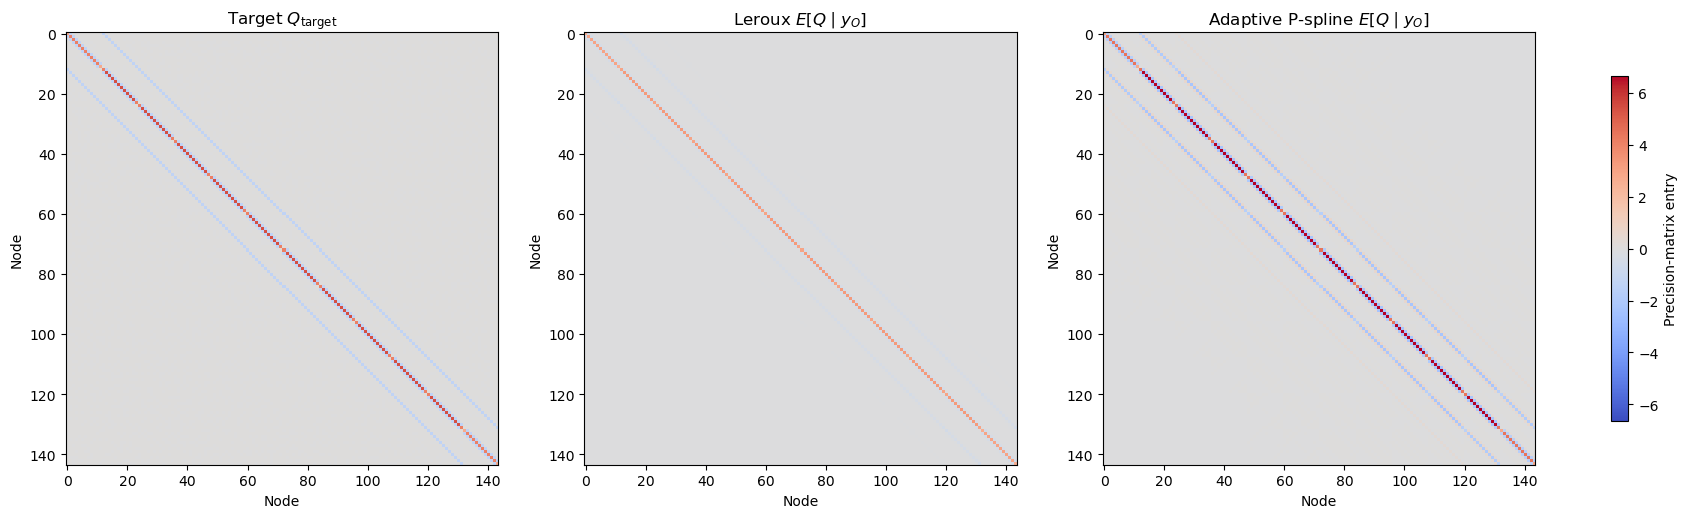

In [35]:
# Use ONE common color scale for all three operators so that
# apparent differences cannot be caused by separate rescaling.

Q_common_limit = max(
    np.max(np.abs(Q_target)),
    np.max(np.abs(Q_leroux_mean)),
    np.max(np.abs(Q_pspline_mean)),
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(17, 5),
    constrained_layout=True,
)

matrices = [
    (
        Q_target,
        r"Target $Q_{\mathrm{target}}$",
    ),
    (
        Q_leroux_mean,
        r"Leroux $E[Q\mid y_O]$",
    ),
    (
        Q_pspline_mean,
        r"Adaptive P-spline $E[Q\mid y_O]$",
    ),
]

images = []

for ax, (matrix, title) in zip(
    axes,
    matrices,
):
    image = ax.imshow(
        matrix,
        cmap="coolwarm",
        vmin=-Q_common_limit,
        vmax=Q_common_limit,
        interpolation="nearest",
        aspect="equal",
    )

    images.append(image)

    ax.set_title(title)
    ax.set_xlabel("Node")
    ax.set_ylabel("Node")

fig.colorbar(
    images[0],
    ax=axes,
    shrink=0.80,
    label="Precision-matrix entry",
)

plt.show()

## 25. Precision-operator difference heatmaps

Plot

$$
E[Q_{\mathrm{Leroux}} \mid y_O]
-
Q_{\mathrm{target}}
$$

and

$$
E[Q_{\mathrm{P\text{-}spline}} \mid y_O]
-
Q_{\mathrm{target}}
$$

using the same symmetric difference scale.

These plots isolate where each posterior mean operator departs from the target.

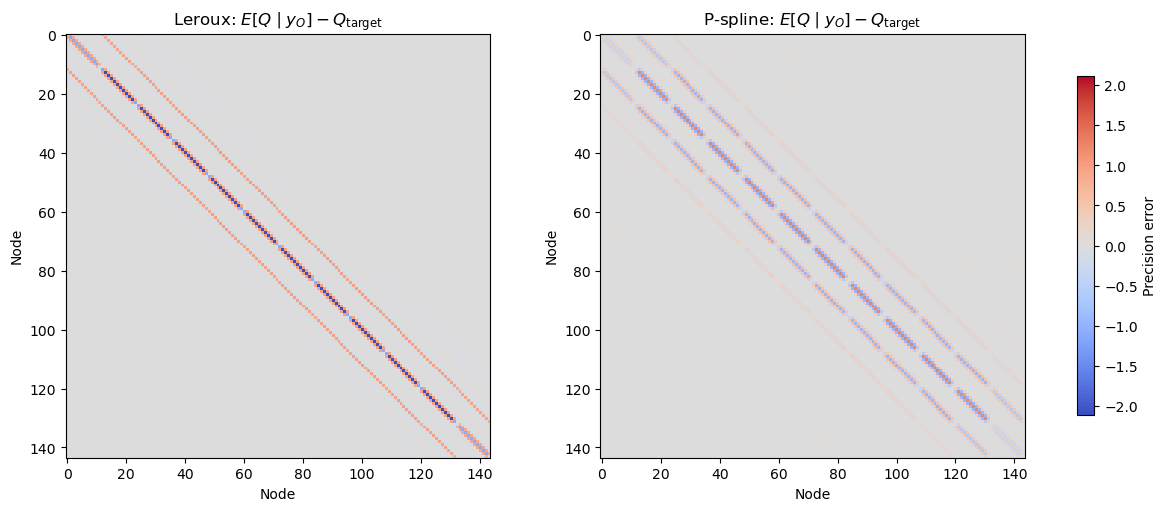

In [36]:
Q_leroux_difference = (
    Q_leroux_mean
    - Q_target
)

Q_pspline_difference = (
    Q_pspline_mean
    - Q_target
)

difference_limit = max(
    np.max(np.abs(Q_leroux_difference)),
    np.max(np.abs(Q_pspline_difference)),
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5),
    constrained_layout=True,
)

difference_matrices = [
    (
        Q_leroux_difference,
        r"Leroux: $E[Q\mid y_O]-Q_{\mathrm{target}}$",
    ),
    (
        Q_pspline_difference,
        r"P-spline: $E[Q\mid y_O]-Q_{\mathrm{target}}$",
    ),
]

images = []

for ax, (matrix, title) in zip(
    axes,
    difference_matrices,
):
    image = ax.imshow(
        matrix,
        cmap="coolwarm",
        vmin=-difference_limit,
        vmax=difference_limit,
        interpolation="nearest",
        aspect="equal",
    )

    images.append(image)

    ax.set_title(title)
    ax.set_xlabel("Node")
    ax.set_ylabel("Node")

fig.colorbar(
    images[0],
    ax=axes,
    shrink=0.80,
    label="Precision error",
)

plt.show()

## 26. Diagonal and off-diagonal precision scatterplots

Compare target versus fitted diagonal entries and target versus fitted off-diagonal entries against a 45-degree reference line.

For the true rook-grid Leroux operator, the diagonal contains a small set of degree-dependent self-precision values, while the off-diagonal contains zeros for non-neighbors and negative values for true rook neighbors.

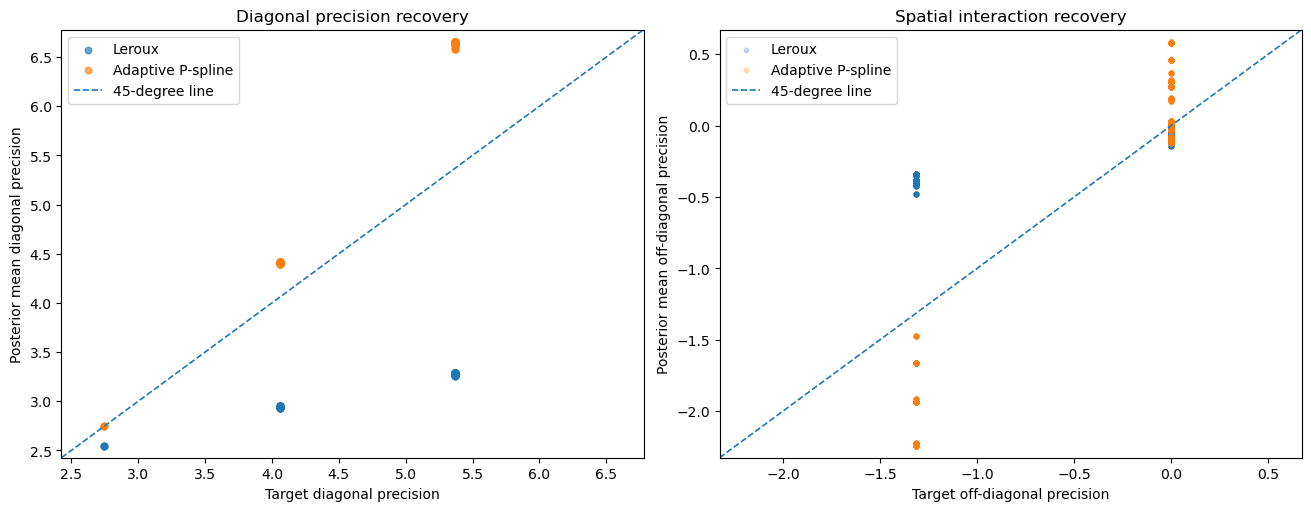

In [37]:
diagonal_mask_matrix = np.eye(
    N,
    dtype=bool,
)

offdiagonal_mask_matrix = (
    ~diagonal_mask_matrix
)

# ------------------------------------------------------------
# Diagonal entries
# ------------------------------------------------------------

target_diag = np.diag(Q_target)
leroux_diag = np.diag(Q_leroux_mean)
pspline_diag = np.diag(Q_pspline_mean)

# ------------------------------------------------------------
# Off-diagonal entries
# ------------------------------------------------------------

target_offdiag = Q_target[
    offdiagonal_mask_matrix
]

leroux_offdiag = Q_leroux_mean[
    offdiagonal_mask_matrix
]

pspline_offdiag = Q_pspline_mean[
    offdiagonal_mask_matrix
]


def add_identity_line(
    ax,
    arrays,
):
    values = np.concatenate(
        [
            np.asarray(x).reshape(-1)
            for x in arrays
        ]
    )

    lower = float(np.min(values))
    upper = float(np.max(values))

    padding = 0.03 * max(
        upper - lower,
        1e-12,
    )

    lower -= padding
    upper += padding

    ax.plot(
        [lower, upper],
        [lower, upper],
        linestyle="--",
        linewidth=1.2,
        label="45-degree line",
    )

    ax.set_xlim(lower, upper)
    ax.set_ylim(lower, upper)


fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5),
    constrained_layout=True,
)

# Diagonal terms
axes[0].scatter(
    target_diag,
    leroux_diag,
    s=22,
    alpha=0.65,
    label="Leroux",
)

axes[0].scatter(
    target_diag,
    pspline_diag,
    s=22,
    alpha=0.65,
    label="Adaptive P-spline",
)

add_identity_line(
    axes[0],
    [
        target_diag,
        leroux_diag,
        pspline_diag,
    ],
)

axes[0].set_xlabel(
    "Target diagonal precision"
)

axes[0].set_ylabel(
    "Posterior mean diagonal precision"
)

axes[0].set_title(
    "Diagonal precision recovery"
)

axes[0].legend()


# Off-diagonal terms
axes[1].scatter(
    target_offdiag,
    leroux_offdiag,
    s=10,
    alpha=0.25,
    label="Leroux",
)

axes[1].scatter(
    target_offdiag,
    pspline_offdiag,
    s=10,
    alpha=0.25,
    label="Adaptive P-spline",
)

add_identity_line(
    axes[1],
    [
        target_offdiag,
        leroux_offdiag,
        pspline_offdiag,
    ],
)

axes[1].set_xlabel(
    "Target off-diagonal precision"
)

axes[1].set_ylabel(
    "Posterior mean off-diagonal precision"
)

axes[1].set_title(
    "Spatial interaction recovery"
)

axes[1].legend()

plt.show()

# PART V — SYNTHESIS

## 27. Final concise findings

This single controlled experiment shows a clear but qualified advantage for adaptive spectral precision modeling under nonlinear eigenvalue misspecification with fixed eigenvectors.

**Main positive result.** The posterior mean Adaptive P-spline precision operator has lower global relative Frobenius error: $0.396$ versus $0.466$ for Leroux, approximately a **15% reduction**. Its largest improvement is in diagonal/self-precision recovery: diagonal RMSE is $1.074$ versus $1.837$, approximately a **42% reduction**.

**Tradeoffs.** The P-spline does not dominate every operator metric. Leroux has slightly lower off-diagonal RMSE, $0.154$ versus $0.162$, and lower relative operator-norm error, $0.591$ versus $0.865$. The adaptive P-spline also shows greater posterior uncertainty in operator recovery.

**Spatial interpretation.** Leroux preserves a sparse interaction structure but systematically attenuates diagonal precision and neighbor coupling under the warped coordinate. The adaptive P-spline corrects much of the dominant global/diagonal bias, but a nonlinear spectral precision function generally induces a denser node-space precision matrix and therefore introduces weak non-neighbor interactions.

**Zero mode.** Removing the constant Laplacian mode changes the results negligibly, so the conclusions are driven by spatially varying modes.

**Scope of the claim.** This experiment supports the narrower statement:

> **Adaptive spectral precision modeling can partially absorb controlled nonlinear eigenvalue misspecification when the eigenvectors are fixed.**

It does **not** establish that SDM-CAR is generally robust to arbitrary misspecification of $W$. That stronger claim requires experiments in which the eigenvectors, as well as the eigenvalues, are perturbed.